# <center> Lecture13 : Hierarchical Models </center>  
 
## <center> Instructor: Dr. Hu Chuan-Peng </center> 

## 回顾  

### 以随机点运动任务为例  

本节课我们依旧以**随机点运动任务**（Random Motion Dot Task）为例，之前的课中，我们仅选取一个被试的例子，但实际上在真实的心理学研究中，我们不会仅针对一个被试进行研究，针对多个被试的反应时间数据，我们要怎么建立模型呢？  

* 参与者的任务是判断这些点的主要移动方向（例如，向左还是向右）。  


![Image Name](https://cdn.kesci.com/upload/image/rkz1ehen1l.png?imageView2/0/w/720/h/960)  

<div style="padding-bottom: 30px;"></div>  



**反应时间数据的挑战：**  

* 被试间的差异：不同被试的反应时间可能有较大差异。  
* 数据偏倚：反应时间可能受到各种因素的影响（如疲劳、动机等），而这些因素在被试间是不一致的。  


* 与传统的频率学派方法不同，贝叶斯方法能够将先验信息（例如，关于群体或个体的预期分布）与数据结合，通过推断逐步修正不确定性，从而得出更精确的估计。  

* 对于多个被试的反应时间数据，贝叶斯层级模型通过引入“群体层”和“个体层”，在建模过程中既考虑到个体差异，也能够捕捉到群体总体趋势，从而更全面地理解反应时间数据背后的复杂结构。


### 大纲  
在本节课中，我们将介绍层级模型(hierarchical model)。主要内容：  
- 了解层级数据结构的形式  
- 三种对待处理层级数据的思路：完全池化(complete pooling),  非池化(no pooling), 部分池化(patial pooling)  
- 了解组间变异(between variability)和组内变异(within variability)的差异  
- 通过pymc实现三种不同的模型，并理解分层模型的意义  

> 注：层级模型有许多别名，多层线性模型（Hierarchical Linear Model，HLM），也叫多水平模型（Multilevel Model，MLM），线性混合模型（Linear Mixed Model）混合效应模型（Mixed Effects Model）随机效应模型（Random Effects Model)

## 层级数据结构  

在心理学实验中，层级数据或分组数据(hierarchical or grouped data)十分常见，例如：  

1. 设计不同的实验条件，在同一实验条件下收集多个数据(实验条件为组)  
2. 划分不同的人群，在同类人群中收集多个数据(人群为组)  
3. 在一种实验条件内，被试需要重复对同种刺激做出反应(被试为组)  

同时，根据下图可以看出，尽管数据内容有所不同，但其层级结构具有高度相似性，均呈现出分层式的组织方式。

无论是学校-系-被试的层次，还是群体-被试-反应时间的结构，数据的组织逻辑都体现为从整体到局部的逐级细分。

![Image Name](https://cdn.kesci.com/upload/sod2y12sei.png?imageView2/0/w/960/h/960)


在之前使用的数据中，层级数据表现为来自多个被试的反应时间数据。

In [310]:
# 安装和加载包
options(repos = c(CRAN = "https://mirrors.tuna.tsinghua.edu.cn/CRAN/"))
if (!requireNamespace('pacman', quietly = TRUE)) {
    install.packages('pacman')
}
pacman::p_load("tidyverse","ggplot2", "dplyr","gridExtra","patchwork","papaja", "bayesplot",
               "rstan","bridgesampling", 'logspline', "easystats", "brms", "RColorBrewer") 
options(warn = -1)  # 抑制警告

In [311]:
# 导入示例数据
df_raw <- tryCatch({
  read.csv('/home/mw/input/bayes3797/evans2020JExpPsycholLearn_exp1_full_data.csv')
}, error = function(e) {
  read.csv('data/evans2020JExpPsycholLearn_exp1_full_data.csv')
})

df_raw[1:10, c("subject", "RT")] # 显示前十行的数据

,subject,RT
,<int>,<int>
1,31727,3529
2,31727,2242
3,31727,979
4,31727,4526
5,31727,7387
6,31727,5082
7,31727,3355
8,31727,2142
9,31727,1135


### 数据可视化  

对所有被试的反应时间的平均值进行可视化，可以发现  

* 不同被试的平均反应时间差异较大 

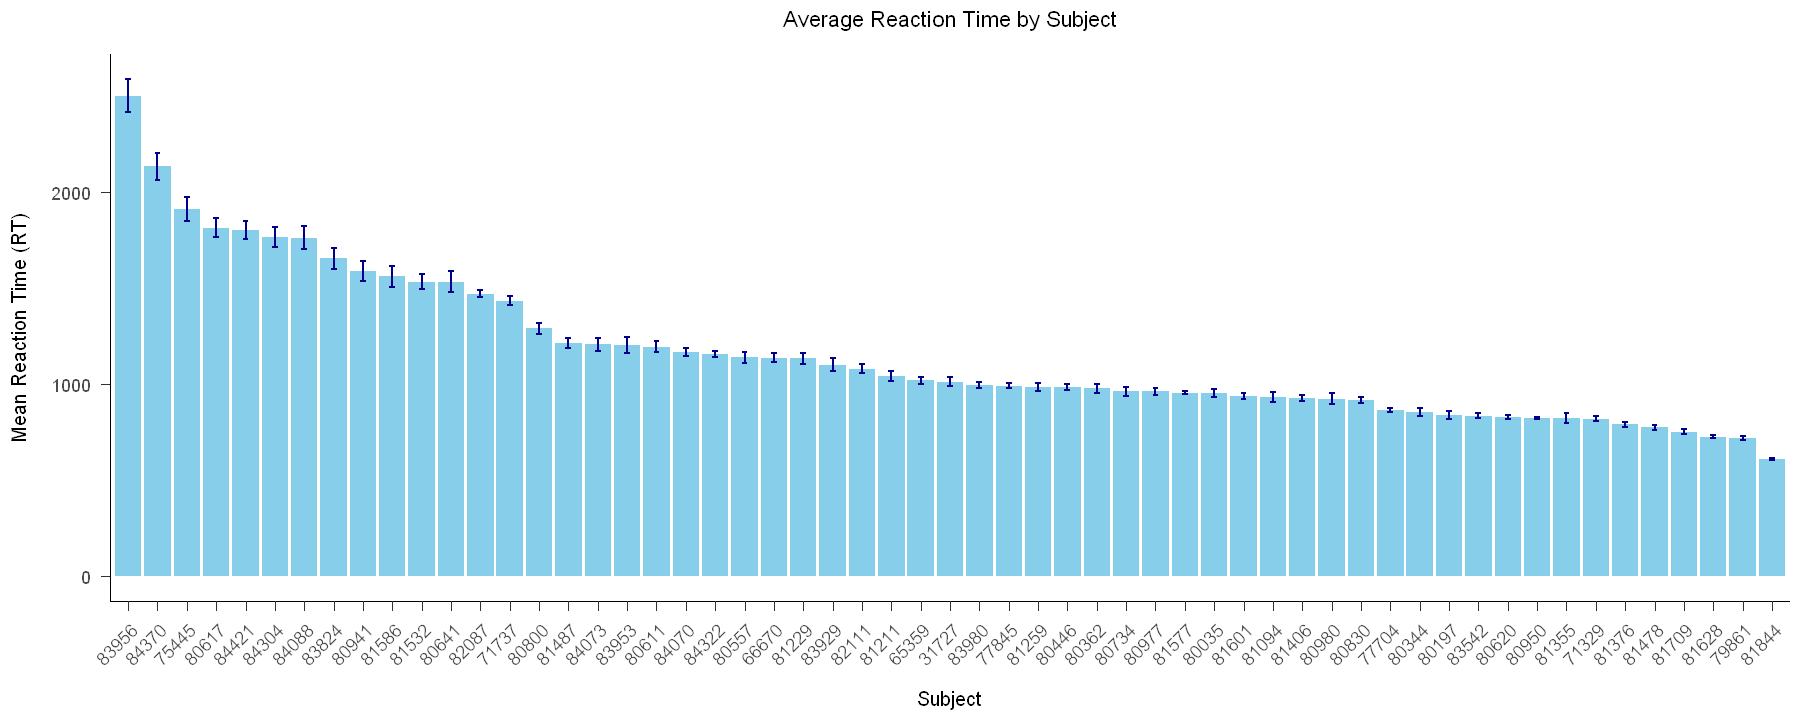

In [312]:
options(repr.plot.width=15, repr.plot.height=6) #自定义画布大小

# 计算每个被试的平均反应时间和标准误差
subject_stats <- df_raw %>%
  dplyr::group_by(subject) %>%
  dplyr::summarise(
    mean = mean(RT, na.rm = TRUE),
    std = sd(RT, na.rm = TRUE),
    count = n()
  ) %>%
  dplyr::ungroup() %>%
  dplyr::mutate(
    sem = std / sqrt(count),
    subject = as.character(subject)  # 转换为字符型
  ) %>%
  dplyr::arrange(dplyr::desc(mean))  # 按平均反应时间从高到低排序

# 绘制平均反应时间的可视化
p <- ggplot2::ggplot(data = subject_stats, ggplot2::aes(x = reorder(subject, -mean), y = mean)) +
  ggplot2::geom_bar(stat = "identity", fill = "skyblue") +
  ggplot2::geom_errorbar(
    ggplot2::aes(ymin = mean - sem, ymax = mean + sem),
    width = 0.2,
    size = 0.8,
    color = "darkblue",
    position = ggplot2::position_dodge(width = 0.9)
  ) +
  ggplot2::labs(
    title = "Average Reaction Time by Subject",
    x = "Subject",
    y = "Mean Reaction Time (RT)"
  ) +
  papaja::theme_apa() +
  ggplot2::theme(
    axis.text.x = ggplot2::element_text(
      angle = 45, # 使横坐标数值倾斜，避免重叠
      hjust = 1,
      vjust = 1
    )
  )

# 显示图形
print(p)

由于被试数量较多，为了使得之后的代码简单和结果清晰，仅使用其中5个被试的数据作为演示。

此外，为了保证数据更加“干净”，仅选择单一的percentCoherence 水平（即 5%）时的RT数据进行分析，避免多种条件混合带来的潜在偏差。

In [313]:
# 筛选出特定被试并创建索引
df_first5 <- df_raw %>%
  dplyr::filter(
    subject %in% c(81844, 83956, 83824, 66670, 80941),  # 筛选特定被试
    percentCoherence == 5  # 筛选percentCoherence等于5的数据
  ) %>%
  dplyr::group_by(subject) %>%
  dplyr::mutate(
    subj_id = subject,
    obs_id = dplyr::row_number(),
    log_RTs = log(RT)
  ) %>%
  dplyr::ungroup()

# 查看数据
head(df_first5)

subject,blkNum,trlNum,coherentDots,numberofDots,percentCoherence,winningDirection,response,correct,eventCount,averageFrameRate,RT,subj_id,obs_id,log_RTs
<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>,<dbl>
66670,2,2,2,40,5,left,left,1,23,15.700,1465,66670,1,7.289611
66670,2,3,2,40,5,left,left,1,25,15.375,1626,66670,2,7.393878
66670,2,6,2,40,5,left,left,1,16,16.113,993,66670,3,6.900731
66670,2,9,2,40,5,left,left,1,13,15.385,845,66670,4,6.739337
66670,2,19,2,40,5,left,left,1,27,15.341,1760,66670,5,7.473069
66670,2,21,2,40,5,right,right,1,22,15.246,1443,66670,6,7.274480


绘制每个被试在percentCoherence为5%时的反应时间直方图，以查看数据分布。 

* 可以发现，不同被试的反应时间分布存在差异，这可能是由于被试之间的个体差异造成的。
* 更重要的是，反应时的分布并不是正态分布，而是偏斜的。

为了正确对反应时分布进行建模，我们需要使用非正态分布的分布，或者将反应时求对数后再通过正态分布进行建模。

* 可以发现，在经过对数转换后，反应时的分布更加接近正态分布。
  
通过对比这两种反应时间分布，我们可以更好地理解数据的特性。

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


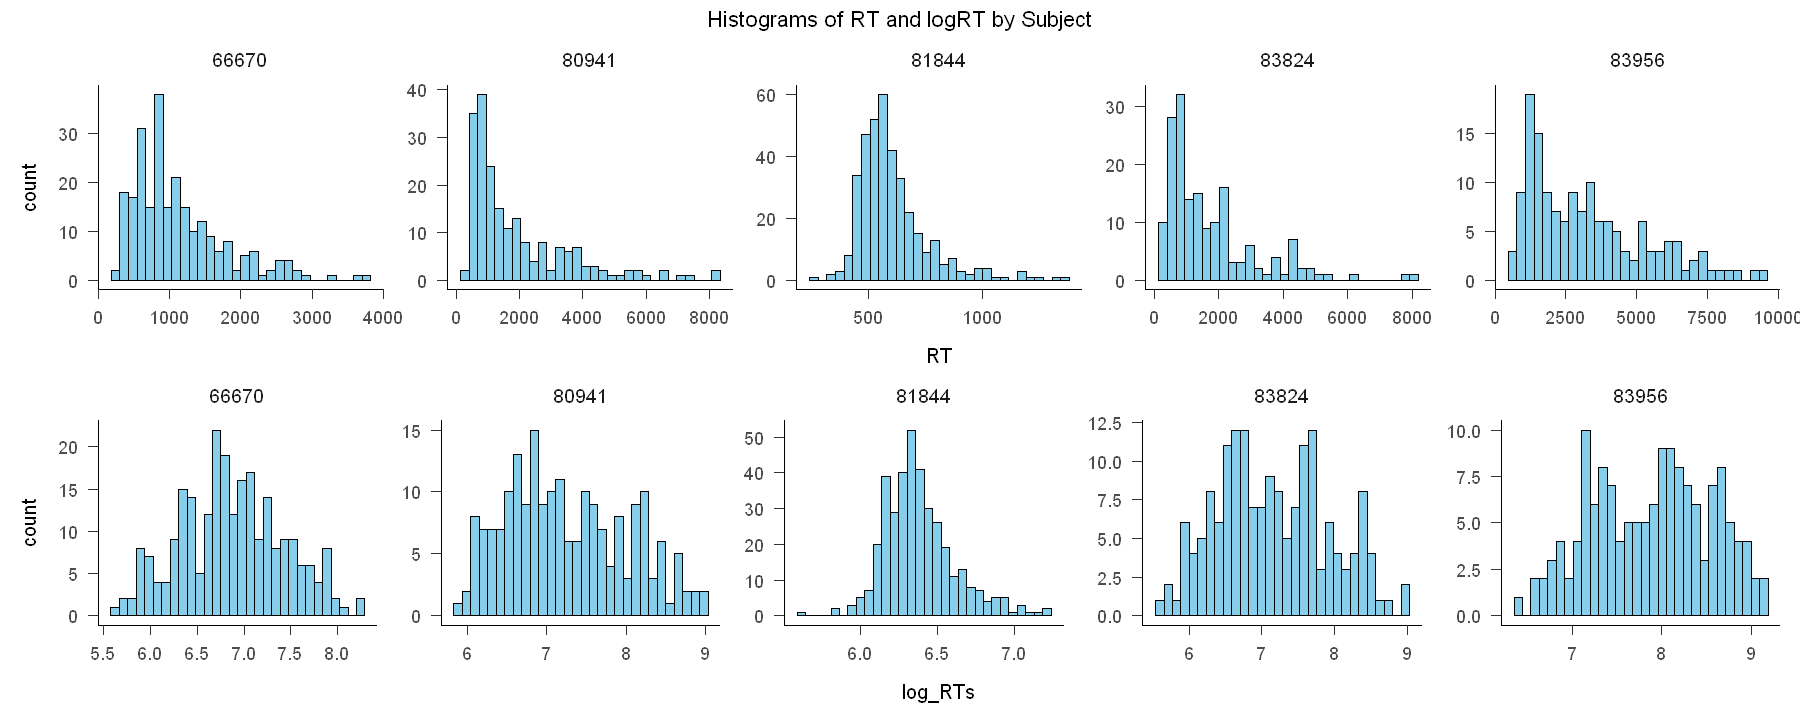

In [314]:
# 设置画布大小
options(repr.plot.width = 15, repr.plot.height = 6)

# 绘制原始RT的直方图（第一行）
p_rt <- ggplot2::ggplot(data = df_first5, ggplot2::aes(x = RT)) +
  ggplot2::geom_histogram(
    fill = "skyblue",
    color = "black",
    bins = 30,
    na.rm = TRUE # 忽略缺失值
  ) +
  ggplot2::facet_wrap(
    ~subject,
    nrow = 1, ncol = 5,
    scales = "free"
  ) +
  ggplot2::theme_bw() +
  papaja::theme_apa()

# 绘制logRT的直方图（第二行）
p_logrt <- ggplot2::ggplot(data = df_first5, ggplot2::aes(x = log_RTs)) +
  ggplot2::geom_histogram(
    fill = "skyblue",
    color = "black",
    na.rm = TRUE
  ) +
  ggplot2::facet_wrap(
    ~subject,
    nrow = 1, ncol = 5,
    scales = "free"
  ) +
  ggplot2::theme_bw() +
  papaja::theme_apa()

# 组合图形
combined_plot <- p_rt / p_logrt +
  patchwork::plot_layout(heights = c(1, 1)) +
  patchwork::plot_annotation(
    title = "Histograms of RT and logRT by Subject",
    theme = ggplot2::theme(plot.title = ggplot2::element_text(hjust = 0.5))
  )

# 显示图形
print(combined_plot)

我们可以使用上节课学习的链接函数（link function）来将反应时数据转换为正态分布。

公式为：

$$
\begin{align*}
\eta = \log(RT)  \\
\eta \sim \mathcal{N}(\mu, \sigma)  \\
\end{align*}
$$

* 其中，$\eta$是反应时的对数，$\mu$和$\sigma$是正态分布的均值和标准差。


注意，由于 RT 经过对数变化后其范围缩小，因此我们对先验进行设置时需要对 $\mu$ 和 $\sigma$ 进行缩放，以保持反应时数据的范围。
* 从上图中可以看出，反应时数据经过对数转换后的范围为 [5,10]。
* 因此，先验 $\mu$ 可以设置为 $\mu ~$，先验 $\sigma$ 的可以设置为: 

$$\begin{align*}
\mu \sim \mathcal{N}(7.5, 5)  \\
\sigma \sim Exp(1)  \\
\end{align*}
$$

- **通过 stan 实现**
  
    ```stan
    # 定义Stan模型
    log_RT_model <- "
    data {
    int<lower=0> N;          // 样本量
    vector[N] logRT;         // 对数转换后的反应时间
    }

    parameters {
    real mu;                 // 均值参数
    real<lower=0> sigma;     // 标准差参数
    }

    model {
    // 先验分布
    mu ~ normal(7.5, 5);     // mu的先验：正态分布N(7.5, 5)
    sigma ~ exponential(1);  // sigma的先验：指数分布Exp(1)
    
    // 似然函数
    logRT ~ normal(mu, sigma);  // 观测值的似然：正态分布N(mu, sigma)
    }
    "
    ```

- **通过 brm 实现**

    ```r
    # 准备数据
    df <- df %>% dplyr::mutate(logRT = log(RT))

    # 拟合brms模型
    log_RT_model_brm <- brms::brm(
    formula = logRT ~ 1,  # 只包含截距项的公式（~1表示只有截距）
    data = df,             # 填入上面的数据
    family = gaussian(),
    prior = c(
        prior(normal(7.5, 5), class = Intercept),  # 截距项mu的先验：N(7.5, 5)
        prior(exponential(1), class = sigma)       # 标准差sigma的先验：Exp(1)
    ))
    ```

<div style="padding-bottom: 50px;"></div>


### 数据的层级结构  

![Image Name](https://cdn.kesci.com/upload/soa517lrnb.jpeg?imageView2/0/w/960/h/960)  



* $j$来表示被试，$j \in \{1,2, \ldots, 5\}$  
* $i$来表示被试内部的每一个数据$i \in \{1,2,\ldots,n_j\}$  
* 每一个被试的数据可以被表示为$Y_{ij}$，表示第$j$个被试的第$i$个试次的反应时间  

$$  
Y := \left((Y_{11}, Y_{21}, \ldots, Y_{n_1,1}), (Y_{12}, Y_{22}, \ldots, Y_{n_2,2}), \ldots, (Y_{1,5}, Y_{2,5}, \ldots, Y_{n_{5},5})\right)  .  
$$  

🤔可以想象，如果我们忽略了数据的分组结构，则可能违反模型使用的前提。  

* 例如，由于反应来自同一个被试，数据点之间是相互关联的，在对被试的反应时使用回归模型时，需要考虑独立性假设是否被违反。  

面对这样的层级数据，我们有三种建模思路(对应三种不同的假设)：  
- 完全池化(complete pooling)  
- 非池化(no pooling)  
- 部分池化(patial pooling)  

## 完全池化(Complete pooling)模型  

* 在完全池化模型中，我们忽略个体的分组信息(Site)，认为这些个体直接来自一个更大的总体  

![Image Name](https://cdn.kesci.com/upload/soa54z159w.png?imageView2/0/w/960/h/960)  




我们可以使用正态模型来建立 complete pooled 模型：  

$$  
\begin{split}  
Y_{ij} | \mu, \sigma & \sim N(\mu, \sigma^2) \\  
\mu    & \sim N(7.5, 5^2) \\  
\sigma & \sim \text{Exp}(1) \\  
\end{split}  
$$  

**global parameters $\theta$**  

* $\mu$为反应时间在**总体**中的均值(global mean)  

* $\sigma$为反应时间均值在**总体**中的标准差(global standard deviation)  

![Image Name](https://cdn.kesci.com/upload/image/rmcx1f4dlx.png?imageView2/0/w/960/h/960)  

> 下图给出了数据中所有被试（n = 57）反应时间的分布情况，大部分反应时间集中在 1000-3000 毫秒 之间

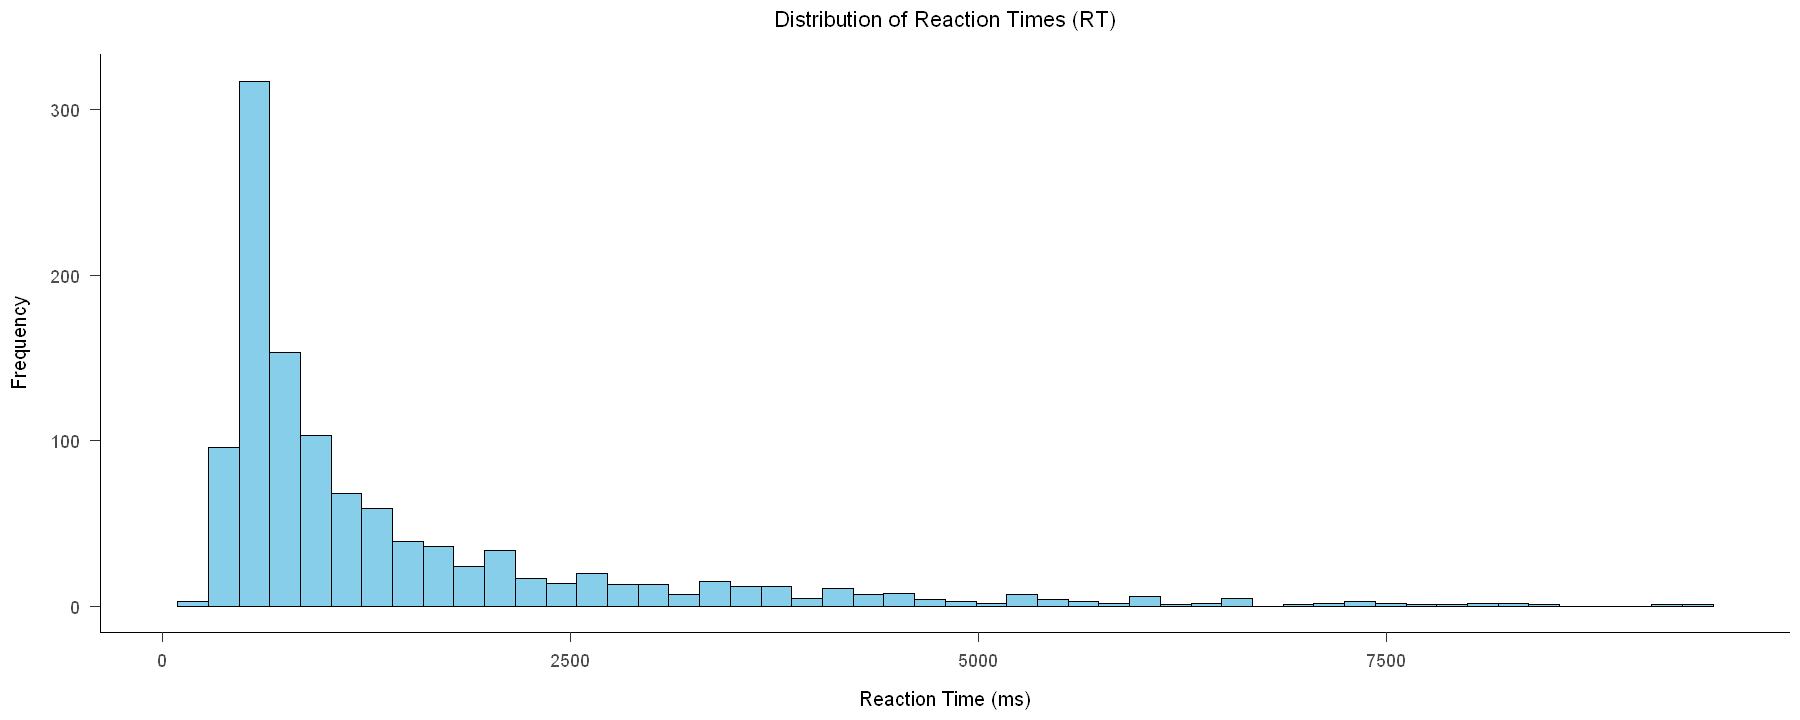

In [315]:
# 绘制所有被试的反应时间 (RT) 的分布图
ggplot2::ggplot(data = df_first5, ggplot2::aes(x = RT)) +
  ggplot2::geom_histogram(
    bins = 50,
    color = "black",
    fill = "skyblue",
  ) +
  papaja::theme_apa() +
  ggplot2::labs(
    title = "Distribution of Reaction Times (RT)",
    x = "Reaction Time (ms)",
    y = "Frequency"
  )

### 模型定义及MCMC采样  

$$  
\begin{split}  
Y_{ij} | \mu, \sigma & \sim N(\mu, \sigma^2) \\  
\mu    & \sim N(7.5, 5^2) \\  
\sigma & \sim \text{Exp}(1) \\  
\end{split}  
$$  

根据公式使用brms定义模型：

In [316]:
# 准备数据：对RT进行log转换
df_first5 <- df_first5 %>% 
  dplyr::mutate(log_RTs = log(RT))

# 拟合完全池化模型
complete_pooled_model <- brms::brm(
  formula = log_RTs ~ 1,  # 只包含截距项，完全池化（忽略被试间差异）
  data = df_first5,
  family = gaussian(),
  # 可以通过 brms::get_prior()查看所对应的class
  prior = c(
    prior(normal(7.5, 5), class = Intercept),  # mu的先验：N(7.5, 5)
    prior(exponential(1), class = sigma)       # sigma的先验：Exp(1)
  ),
  chains = 4,
  iter = 2000,
  warmup = 1000,
  seed = 84735,
  control = list(adapt_delta = 0.95)
)

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.00149 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 14.9 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.167 seconds (Warm-up)
Chain 1:                0.186 seconds (Sampling)
Chain 1:                0.35

### 查看后验参数估计

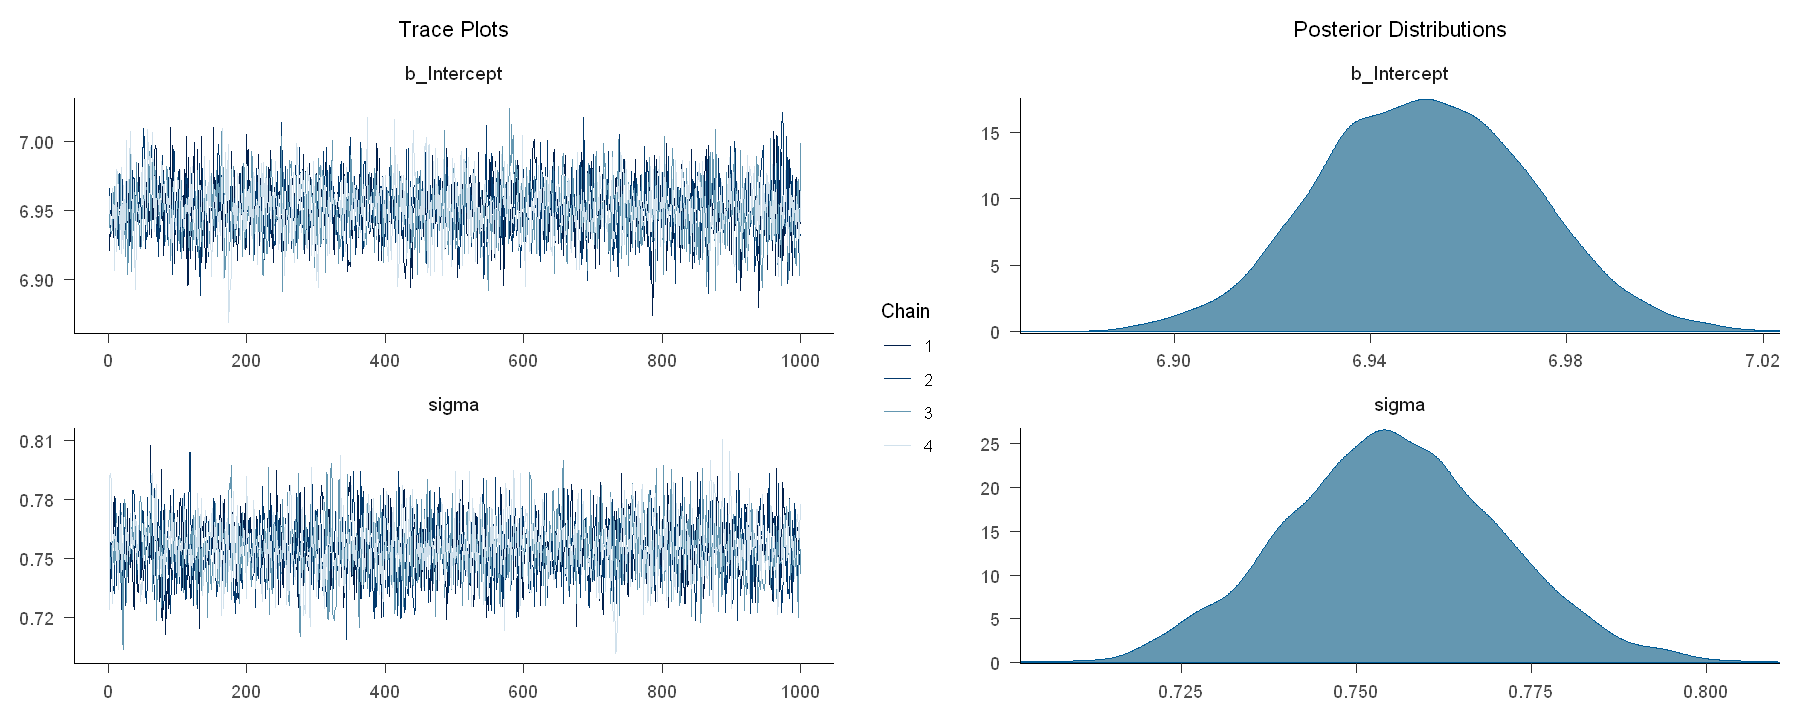

In [317]:
# 从 brms 模型中提取后验样本
posterior_samples <- as.array(complete_pooled_model)

# 绘制迹图（trace plot）
trace_plot <- bayesplot::mcmc_trace(
  posterior_samples,  # 后验样本数组
  pars = c("b_Intercept", "sigma"),  # 要绘制的参数
  facet_args = list(nrow = 2, ncol = 1)
) +
  ggplot2::labs(title = "Trace Plots") +
  papaja::theme_apa()

# 绘制后验分布图
dens_plot <- bayesplot::mcmc_dens(
  posterior_samples,
  pars = c("b_Intercept", "sigma"),
  facet_args = list(nrow = 2, ncol = 1),
) +
  ggplot2::labs(title = "Posterior Distributions") +
  papaja::theme_apa()


# 显示图形
trace_plot + dens_plot

In [318]:
summary(complete_pooled_model)

 Family: gaussian 
  Links: mu = identity; sigma = identity 
Formula: log_RTs ~ 1 
   Data: df_first5 (Number of observations: 1142) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept     6.95      0.02     6.91     6.99 1.00     2614     2023

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     0.76      0.02     0.73     0.79 1.00     2789     2007

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at convergence, Rhat = 1).

由于RT 已经进行了 log 变换，所以后验均值 mu 的真实值应为 1392。

使用以下公式可以将 mu 转换为 RT 的真实值：
$$
RT_{mean} = e^{\mu_{mean} + \sigma_{mean}^2/2}
$$

In [319]:
# 定义逆对数转换函数
inv_log <- function(mu, sigma) {
  exp(mu + (sigma^2) / 2)
}

# 计算预测的RT均值
pred_rt <- inv_log(6.95, 0.76)

# 打印结果（保留3位小数）
cat("The estimated mean of RT is: ", round(pred_rt, 3), "\n")

The estimated mean of RT is:  1392.422 


In [320]:
# 从brms模型中提取mu的后验均值
mu_posterior_mean <- brms::fixef(complete_pooled_model)["Intercept", "Estimate"]

# 计算真实log RT的均值
truth_log_rt_mean <- mean(log(df_first5$RT))

# 打印结果
cat("The posterior mean of mu is: ", round(mu_posterior_mean, 3), "\n")
cat("The truth log RT mean is:", round(truth_log_rt_mean, 3), "\n")

The posterior mean of mu is:  6.951 
The truth log RT mean is: 6.951 


### 后验预测分布  

* 画出所有预测值的95%后验预测可信区间  

* 同时可以观察真实值落在可信区间的情况  

> (在之前的课件中已介绍过可信区间的绘制，主要借助`summary`生成后验预测总结的表格，并判断真实值是否落在可信区间内)

Using 10 posterior draws for ppc type 'dens_overlay' by default.



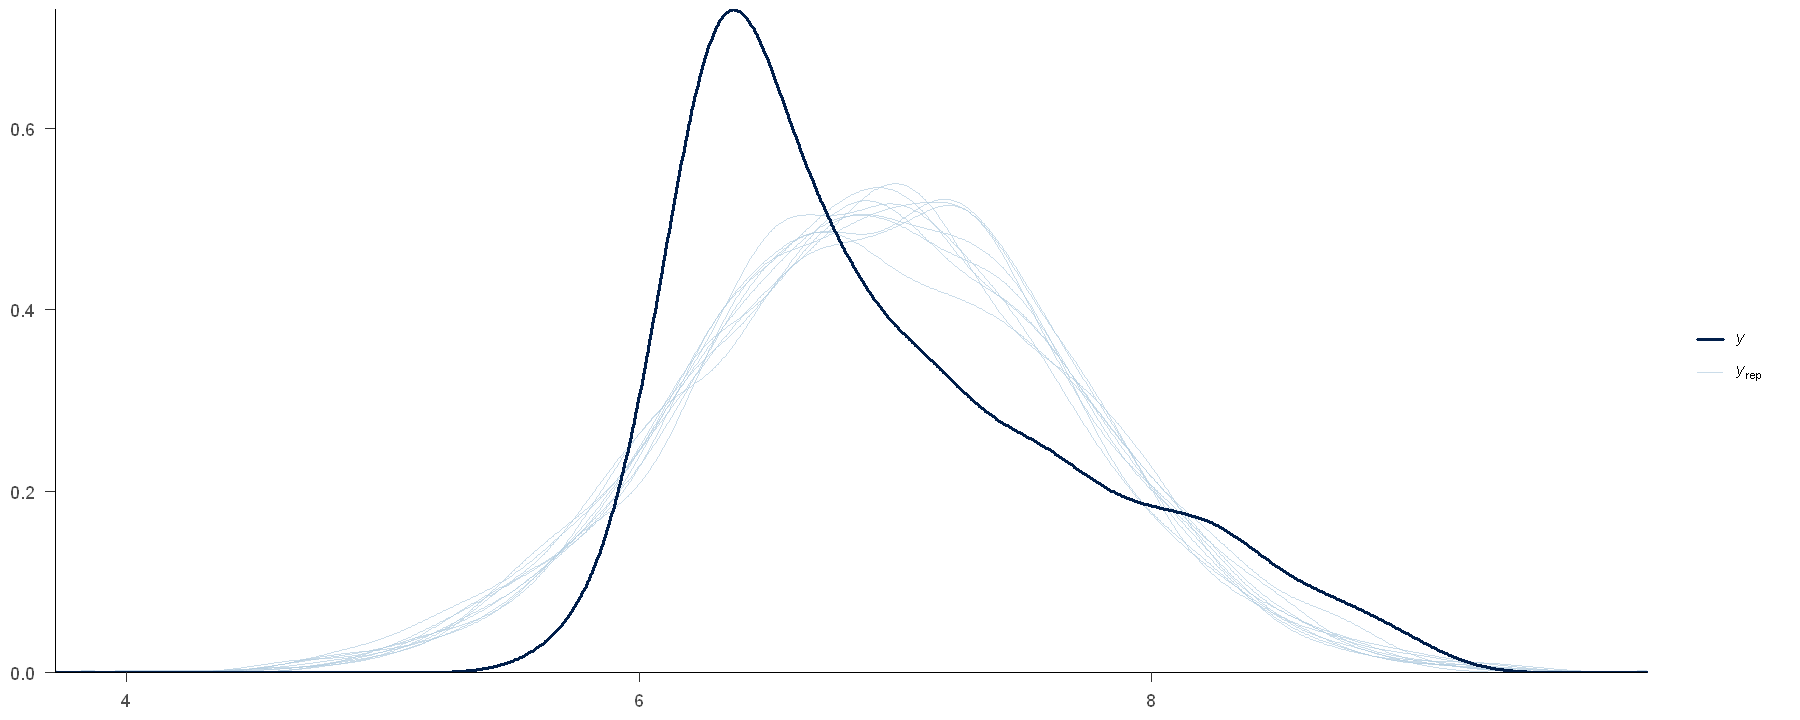

In [321]:
# 进行后验预测检查
bayesplot::pp_check(complete_pooled_model) +
papaja::theme_apa()

In [ ]:
ppc_sum <- function(ppc, data, y = "RT") {
  # 计算每个观测值的后验预测均值
  ppc_mean <- apply(ppc, 2, mean)
  
  # 计算每个观测值的后验预测标准差
  ppc_sd <- apply(ppc, 2, sd)
  
  # 计算每个观测值的95% HDI
  ppc_hdi <- t(apply(ppc, 2, function(x) {
    hdi_result <- bayestestR::hdi(x, ci = 0.95) 
    # 直接提取 CI_low 和 CI_high 列
    return(c(hdi_result$CI_low, hdi_result$CI_high))
  }))
  
  # 设置HDI矩阵的列名
  colnames(ppc_hdi) <- c("Q2.5", "Q97.5")
  
  # 构建结果数据框
  hdi_sum <- base::data.frame(
    mean = ppc_mean,              # 后验预测均值
    sd = ppc_sd,                  # 后验预测标准差
    Q2.5 = ppc_hdi[, "Q2.5"],     # 95% HDI下限
    Q97.5 = ppc_hdi[, "Q97.5"],   # 95% HDI上限
    y = data[[y]],                # 原始观测值
    obs_id = 1:nrow(data),        # 观测ID
    subject = data[["subject"]]   # 被试ID
  )
  
  return(hdi_sum)
}

In [323]:
# 生成后验预测
ppc <- brms::posterior_predict(complete_pooled_model)

# 调用函数计算HDI
hdi_sum <- ppc_sum(ppc, data = df_first5, y = "RT")

# 查看结果
head(hdi_sum)

,mean,sd,Q2.5,Q97.5,y,obs_id,subject
,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
1,6.967801,0.7482077,5.411479,8.354836,1465,1,66670
2,6.947104,0.7474812,5.348448,8.257436,1626,2,66670
3,6.951825,0.7604028,5.510171,8.470748,993,3,66670
4,6.952251,0.7576176,5.496434,8.439796,845,4,66670
5,6.959064,0.7564928,5.452335,8.434830,1760,5,66670
6,6.971304,0.7559137,5.526816,8.454421,1443,6,66670


由于 mean 和 hdi 也是收到对数化影响的, 因此需要对数据进行逆对数转换：

In [324]:
inv_log_hdi_sum <- function(hdi_sum) {
  # 对均值、HDI下限和上限进行逆对数转换
  df <- dplyr::mutate(
    hdi_sum,
    mean = inv_log(mean, sd),  # 转换均值
    Q2.5 = inv_log(Q2.5, sd),   # 转换2.5%分位数（HDI下限）
    Q97.5 = inv_log(Q97.5, sd)  # 转换97.5%分位数（HDI上限）
  )
  
  return(df)
}
complete_hdi_sum <- inv_log_hdi_sum(hdi_sum)
head(complete_hdi_sum)

,mean,sd,Q2.5,Q97.5,y,obs_id,subject
,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
1,1404.882,0.7482077,296.3042,5623.692,1465,1,66670
2,1375.356,0.7474812,278.0531,5099.000,1626,2,66670
3,1395.393,0.7604028,330.0609,6373.182,993,3,66670
4,1393.039,0.7576176,324.8703,6165.893,845,4,66670
5,1401.368,0.7564928,310.5907,6130.128,1760,5,66670
6,1418.006,0.7559137,334.4606,6248.670,1443,6,66670


由于我们省略了分组信息，假测所有的观测值都来自同一正态分布，因此所有观测值的后验预测均值都是相似的  
* 纵坐标为反应时的范围  
* 横坐标代表每个观测值根据不同被试的排序  
* 黑色横线部分表示每个观测值的后验预测均值

In [ ]:
# 定义PPC绘图函数
ppc_plot <- function(hdi_sum, show_plot = TRUE) {
  df <- hdi_sum
  
  # 重置索引，创建obs_id列
  df <- dplyr::mutate(df, obs_id = dplyr::row_number() - 1)
  
  # 确保subject列是因子类型
  df <- dplyr::mutate(df, subject = as.factor(subject))
  
  # 选择Seaborn调色板
  n_subjects <- length(unique(df$subject))
  palette <- RColorBrewer::brewer.pal(n = min(8, n_subjects), name = "Set2")
  if (n_subjects > 8) {
    palette <- grDevices::colorRampPalette(palette)(n_subjects)
  }
  
  # 创建颜色映射向量（为每个subject分配一个颜色）
  subject_colors <- stats::setNames(palette, levels(df$subject))
  
  # 映射颜色到新列
  df <- dplyr::mutate(df,
    # 深色：用于散点
    color_dark = subject_colors[as.character(subject)],
    # 浅色：用于HDI区间
    color_light = scales::alpha(subject_colors[as.character(subject)], 0.3)
  )
  
  # 根据是否落在可信区间内分配颜色
  df <- dplyr::mutate(df,
    color_dark = ifelse(
      (y >= Q2.5) & (y <= Q97.5), 
      color_dark, "#C00000"  # 红色表示超出HDI
    )
  )
  
  # 计算每个被试的中心位置，用于x轴刻度
  subject_centers <- dplyr::group_by(df, subject) %>%
    dplyr::summarise(min_id = min(obs_id), max_id = max(obs_id), center = (min_id + max_id) / 2,
    .groups = "drop"
    )
  
  # 创建ggplot对象
  p <- ggplot2::ggplot(df, ggplot2::aes(x = obs_id)) +
    
    # 绘制94%可信区间
    ggplot2::geom_linerange(
      ggplot2::aes(ymin = Q2.5, ymax = Q97.5),
      color = df$color_light, alpha = 0.1, size = 3, show.legend = FALSE
    ) +
    
    # 各被试散点图数据
    ggplot2::geom_point(
      ggplot2::aes(y = y), color = df$color_dark, alpha = 0.8, size = 3
    ) +
    
    # 绘制后验预测均值（使用横线标记）
    ggplot2::geom_point(
      ggplot2::aes(y = mean), shape = "_", color = "black", alpha = 0.7,
      size = 5, show.legend = FALSE
    ) +
    
    # 设置x轴刻度（按被试分组
    ggplot2::scale_x_continuous(
      breaks = subject_centers$center,
      labels = subject_centers$subject,
      expand = ggplot2::expansion(add = c(0.5, 0.5))
    ) +
    
    # 设置图形标题和标签
    ggplot2::labs(
      title = "Posterior Predictive Check (PPC) by Subject",
      x = "Subject ID",
      y = "Reaction Time (ms)"
    ) +
    papaja::theme_apa() +
    
    # 添加图例文本
    ggplot2::annotate(
      "text",
      x = Inf, y = Inf,
      label = "Outside HDI: Red points\n94% HDI: Light lines\nPosterior mean: Black dashes",
      hjust = 1.1, vjust = 1.1, size = 3.5
    )
  
  # 显示图形或返回ggplot对象
  if (show_plot) {
    print(p)
    return(invisible(p))
  } else {
    return(p)
  }
}

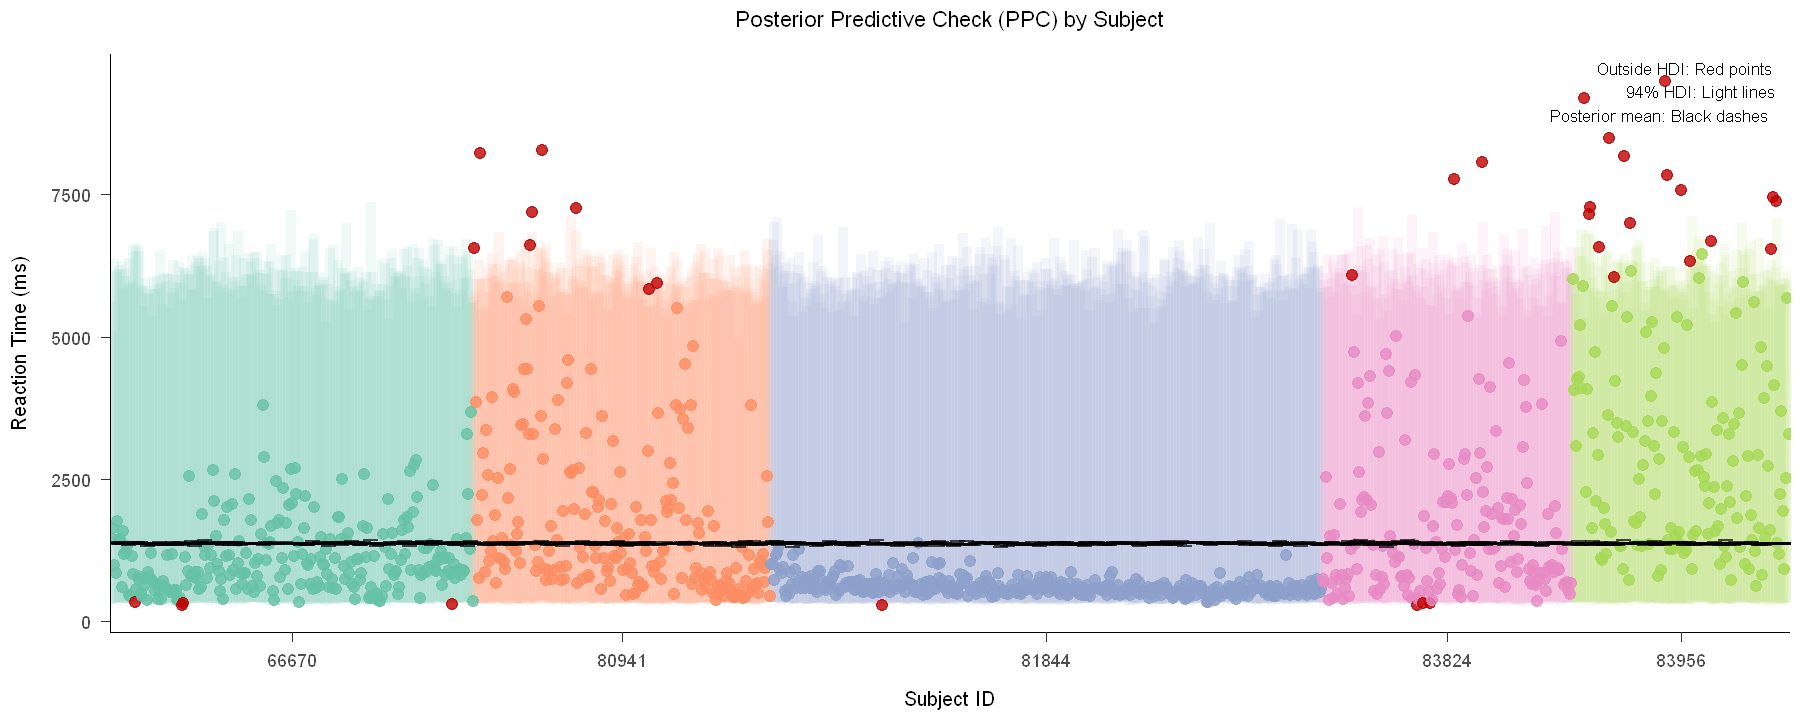

In [326]:
ppc_plot(hdi_sum=complete_hdi_sum)

## No pooling 非池化模型  

在complete pooled模型中，我们忽略了数据来自不同的被试这一事实  

现在我们考虑另外一种情况，我们**假设五个被试分别来自不同的分布，对五个被试进行不同的分析**  
* 注意：我们假定，每个被试的数据之间完全没有关联，不同被试之间彼此独立。  
* 从统计上讲，假定各被试之间的参数(例如均值$\mu$)没有关系，或者说是完全异质。  



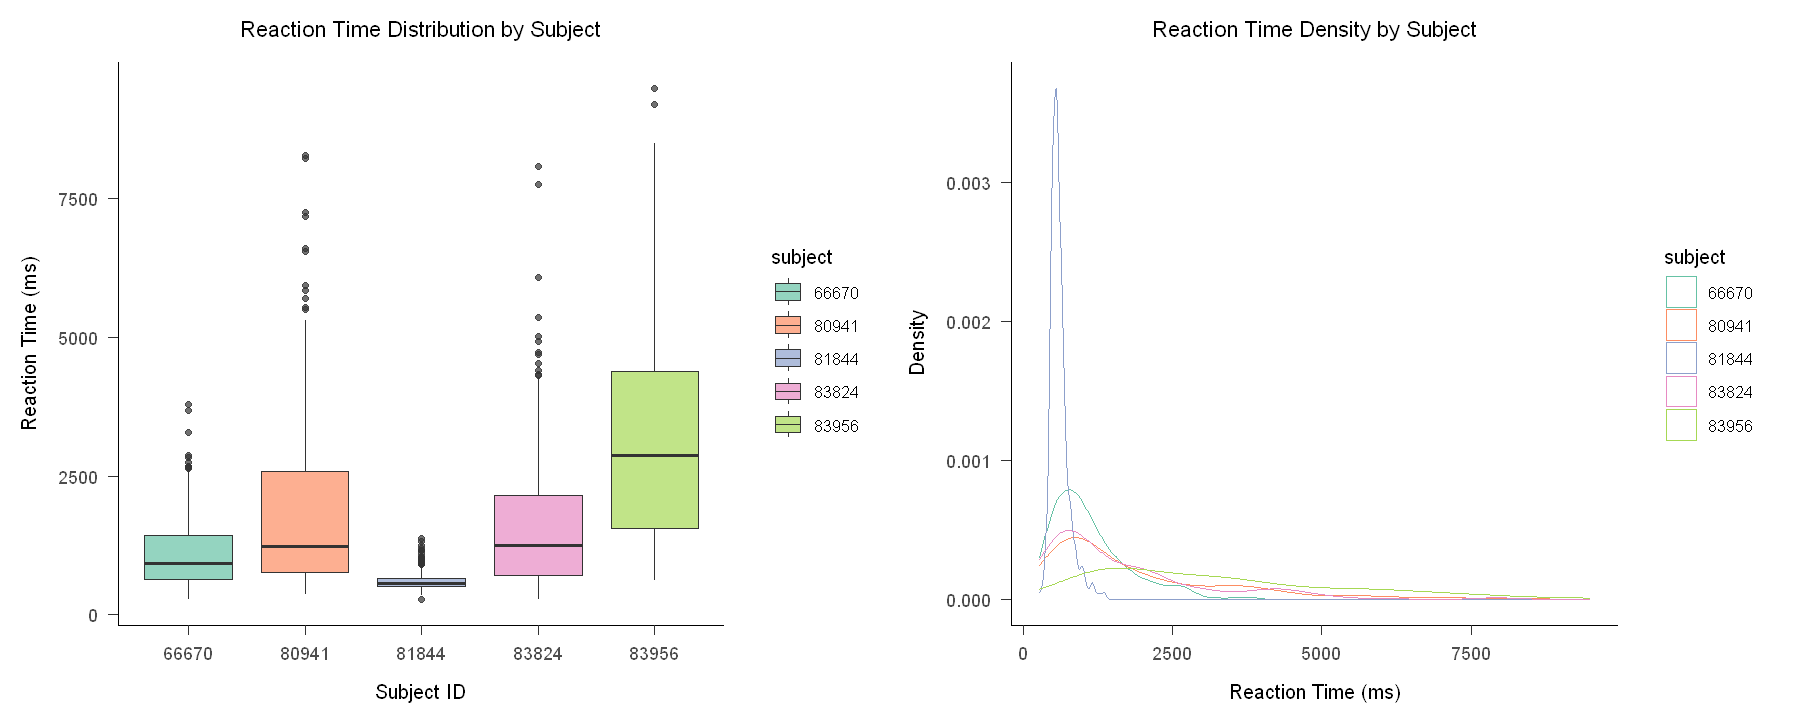

In [327]:
# 将subject转换为因子型
df_first5_processed <- dplyr::mutate(
  df_first5,
  subject = as.factor(subject)
)

# 创建左侧箱线图：显示每个被试的反应时间分布
boxplot_plot <- ggplot2::ggplot(df_first5_processed, ggplot2::aes(x = subject, y = RT, fill = subject)) +
  ggplot2::geom_boxplot(alpha = 0.7) +
  ggplot2::scale_fill_brewer(palette = "Set2") +
  ggplot2::labs(
    title = "Reaction Time Distribution by Subject",
    x = "Subject ID",
    y = "Reaction Time (ms)"
  ) +
  papaja::theme_apa()

# 创建右侧核密度估计图：显示每个被试的反应时间密度分布
kde_plot <- ggplot2::ggplot(df_first5_processed, ggplot2::aes(x = RT, color = subject)) +
  ggplot2::geom_density(alpha = 0.5, common_norm = FALSE) +
  ggplot2::scale_color_brewer(palette = "Set2") +
  ggplot2::scale_fill_brewer(palette = "Set2") +
  ggplot2::labs(
    title = "Reaction Time Density by Subject",
    x = "Reaction Time (ms)",
    y = "Density"
  ) +
  papaja::theme_apa()

# 组合图形
boxplot_plot + kde_plot

### Group-specific parameters  

* 在完全池化模型中，我们使用了正态分布的参数来自总体层面；  

* 在非池化模型中，我们认为正态分布的参数在组与组之间是不同的(group-specific) ---- 可以认为每个被试的数据对应一个独立的正态分布模型  

![Image Name](https://cdn.kesci.com/upload/soa6opcohm.png?imageView2/0/w/960/h/960)  

1. 使用 $\mu_j$ 来表示每个被试的反应时间均值  

    * 不同被试的$\mu_j$不同  

    * 同一被试内的trial服从以 $\mu_j$ 为均值的正态分布模型  

3. 同样，使用 $\sigma_j$ 来表示每个被试内部每个trial的反应时间的变异性  

    * 和 $\mu_j$ 类似，不同被试的 $\sigma_j$ 不同  
    * 同一被试内的个体服从以 $\sigma_j$ 为标准差的正态分布模型  

则对于被试 $j$ 内的每个trial来说，反应时间满足：  
$$  
Y_{ij} | \mu_j, \sigma \sim N(\mu_j, \sigma_j^2) \\  

\mu_j  \sim N(7.5, 5^2) \\  

\sigma_j \sim \text{Exp}(1) \\  
$$  
![Image Name](https://cdn.kesci.com/upload/soa6opcohm.png?imageView2/0/w/960/h/960)

### 模型定义及MCMC采样  

根据公式定义模型：  

$$  
Y_{ij} | \mu_j, \sigma \sim N(\mu_j, \sigma_j^2) \\  

\mu_j  \sim N(7.5, 5^2) \\  

\sigma_j \sim \text{Exp}(1) \\  
$$  

- 考虑到数据有5个被试，即 j = 1,2,3,4,5。因此，$\mu_j$ 和 $\sigma_j$ 也有5个值。  

In [119]:
prior_structure <- get_prior(
  formula = bf(
    log(RT) ~ 0 + subject,  # 均值模型：每个subject独立截距（mu）
    sigma ~ 0 + subject      # 标准差模型：每个subject独立标准差（sigma）
  ), 
  sigma ~ 0 + subject,
  data = df_first5,
  family = gaussian()
)
print(prior_structure)

  prior class         coef group resp  dpar nlpar lb ub       source
 (flat)     b                                                default
 (flat)     b subject66670                              (vectorized)
 (flat)     b subject80941                              (vectorized)
 (flat)     b subject81844                              (vectorized)
 (flat)     b subject83824                              (vectorized)
 (flat)     b subject83956                              (vectorized)
 (flat)     b                         sigma                  default
 (flat)     b subject66670            sigma             (vectorized)
 (flat)     b subject80941            sigma             (vectorized)
 (flat)     b subject81844            sigma             (vectorized)
 (flat)     b subject83824            sigma             (vectorized)
 (flat)     b subject83956            sigma             (vectorized)


In [328]:
df_first5 <- df_first5 %>% 
  dplyr::mutate(subject = as.factor(subject))

# 定义非池化模型
no_pooled_model <- brm(
  # log(RT)作为响应变量，每个subject有自己的截距
  formula = bf(
    log(RT) ~ 0 + subject,
    sigma ~ 0 + subject
  ),
  data = df_first5,
  family = gaussian(),
  # 为使模型收敛，此处不自定义先验
  chains = 4,
  iter = 2000,
  warmup = 1000,
  seed = 84735,
  control = list(adapt_delta = 0.95)
)

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000503 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 5.03 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 2.597 seconds (Warm-up)
Chain 1:                1.705 seconds (Sampling)
Chain 1:                4.3

### 查看后验参数估计  

- 可以发现，对于每个被试，均有不同的参数值 (包括 $\mu$ 和 $\sigma$)

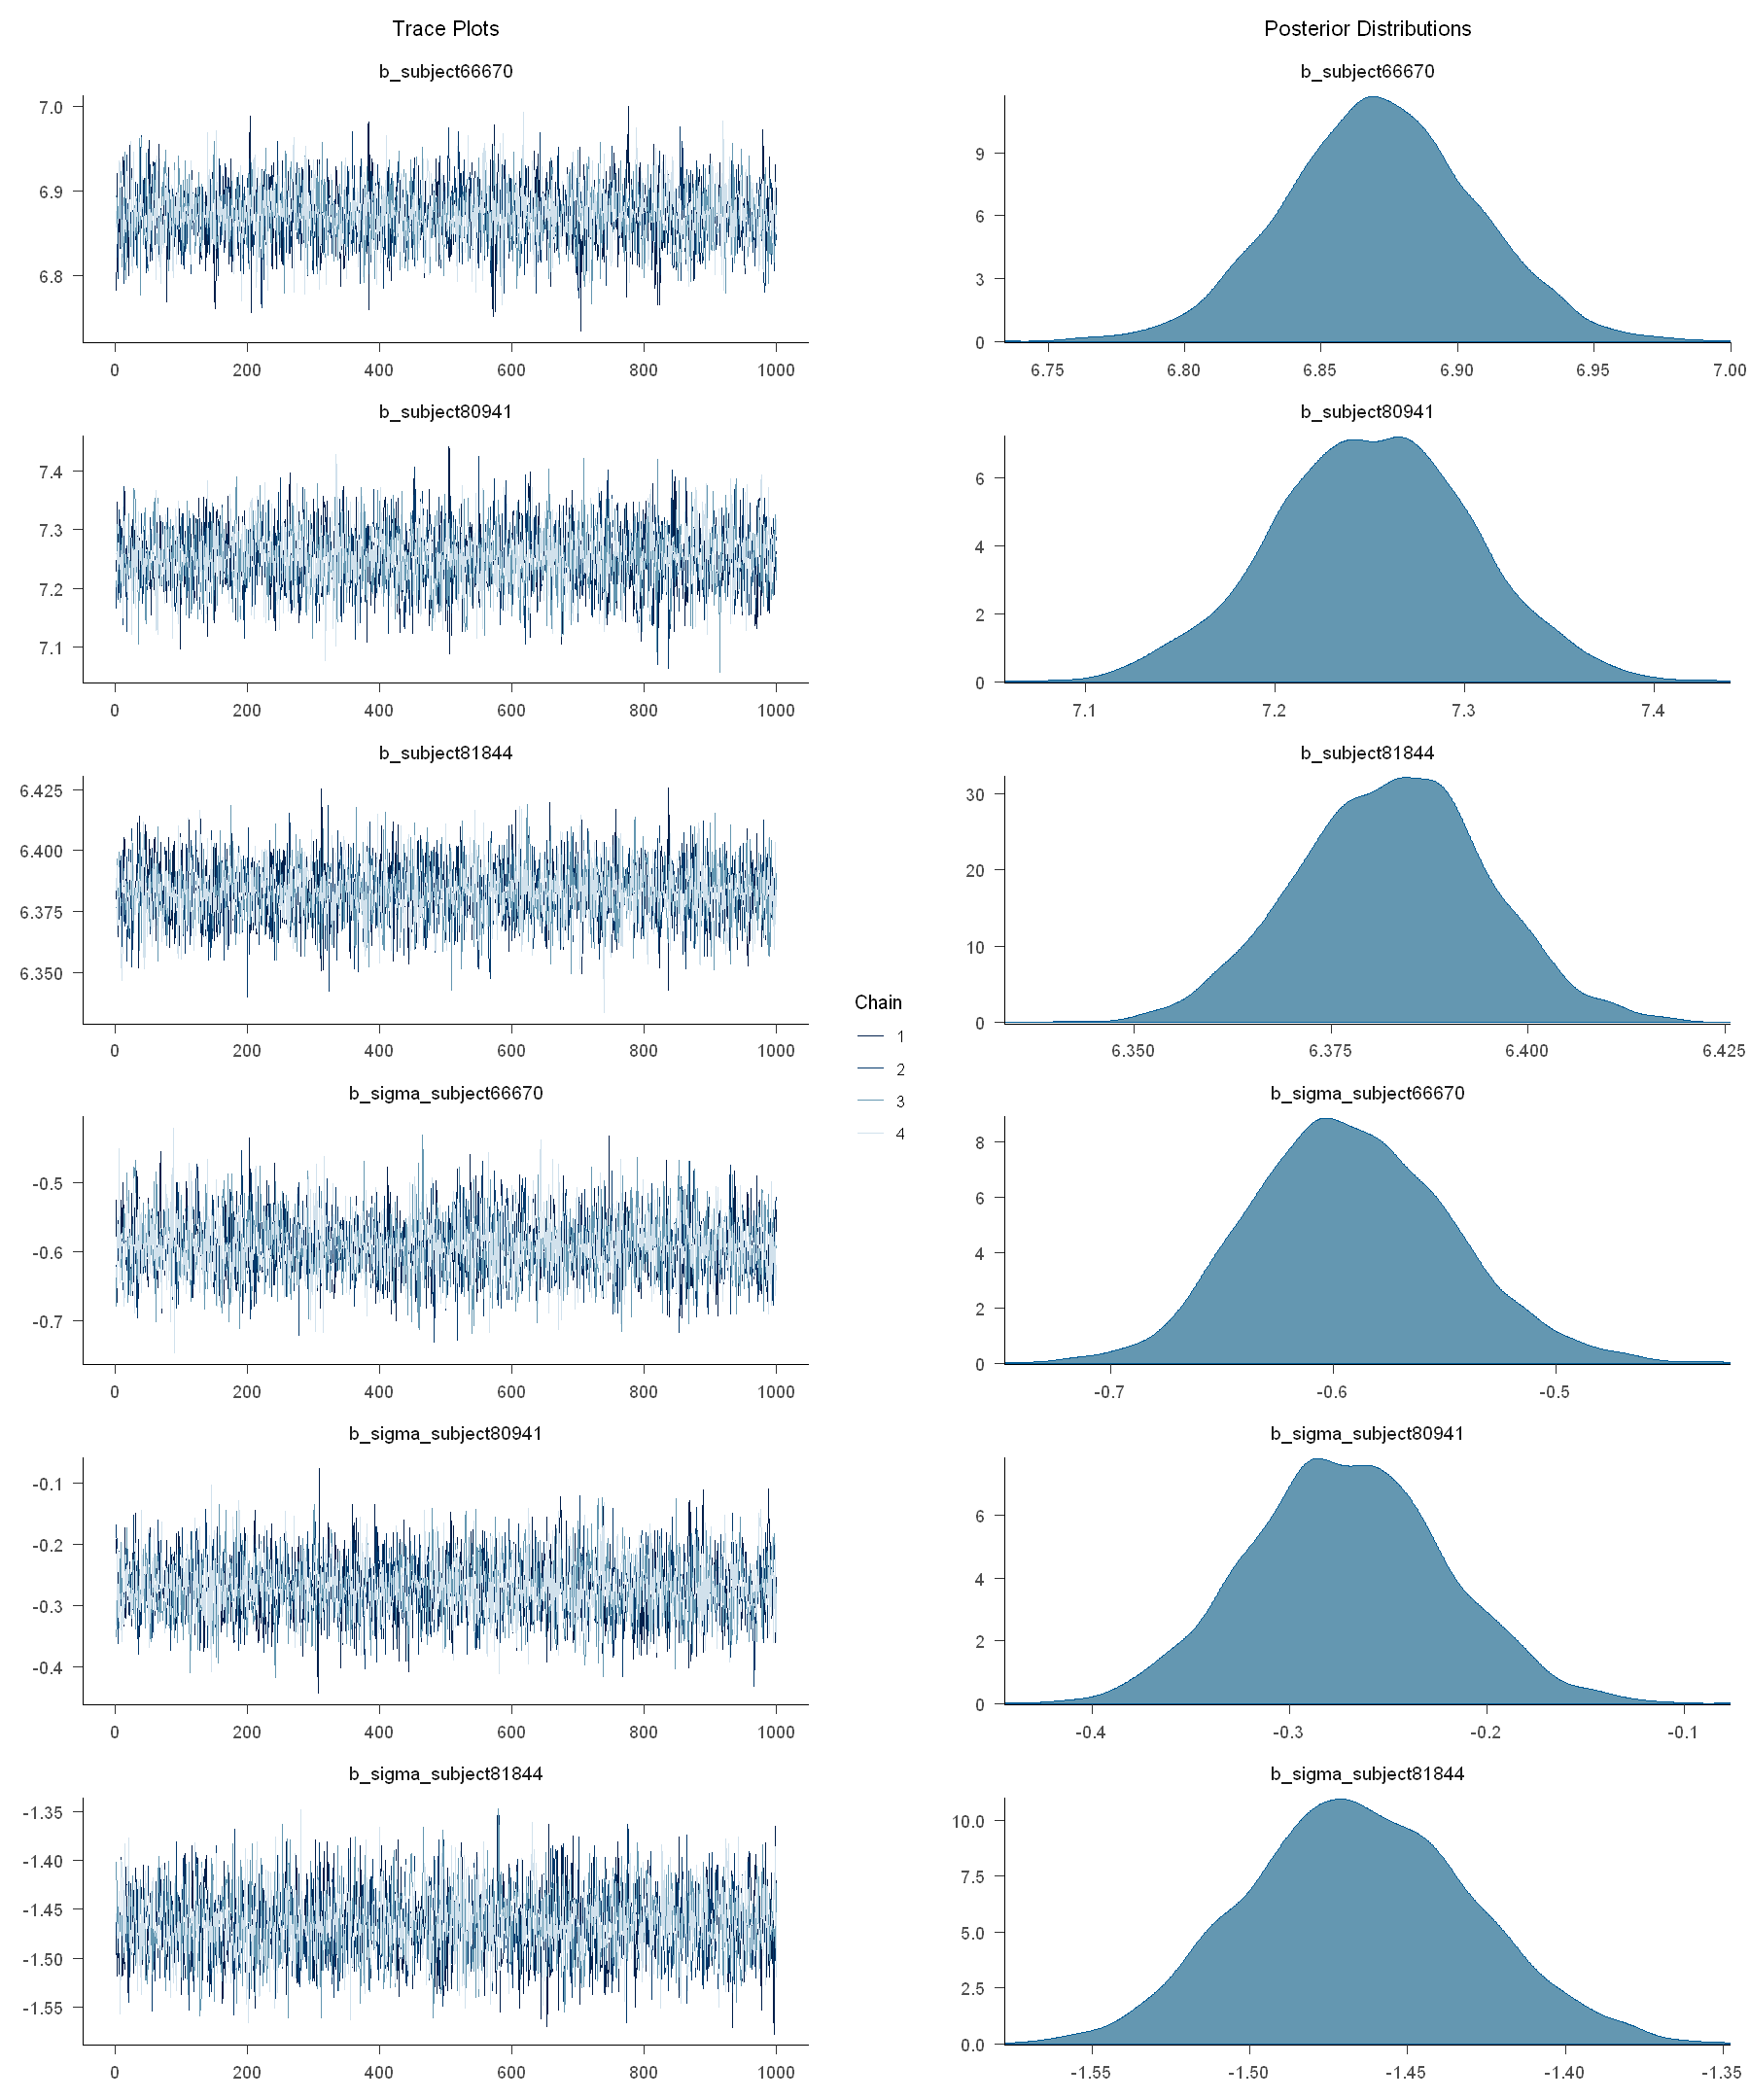

In [329]:
options(repr.plot.width = 15, repr.plot.height = 18)

# 从 brms 模型中提取后验样本
posterior_samples <- as.array(no_pooled_model)

# 选择要绘制的参数（以其中三个被试为例）
target_pars <- c(
  "b_subject66670",
  "b_subject80941",
  "b_subject81844",
  "b_sigma_subject66670",
  "b_sigma_subject80941",
  "b_sigma_subject81844")

# 绘制迹图（trace plot）
trace_plot <- bayesplot::mcmc_trace(
  posterior_samples,  # 后验样本数组
  pars = target_pars,  # 要绘制的参数
  facet_args = list(nrow = 6, ncol = 1)
) +
  ggplot2::labs(title = "Trace Plots") +
  papaja::theme_apa()

# 绘制后验分布图
dens_plot <- bayesplot::mcmc_dens(
  posterior_samples,
  pars = target_pars,
  facet_args = list(nrow = 6, ncol = 1),
) +
  ggplot2::labs(title = "Posterior Distributions") +
  papaja::theme_apa()


# 显示图形
trace_plot + dens_plot

In [330]:
summary(no_pooled_model)

 Family: gaussian 
  Links: mu = identity; sigma = log 
Formula: log(RT) ~ 0 + subject 
         sigma ~ 0 + subject
   Data: df_first5 (Number of observations: 1142) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Regression Coefficients:
                   Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
subject66670           6.87      0.04     6.80     6.94 1.00     5215     3107
subject80941           7.25      0.05     7.14     7.35 1.00     4499     2946
subject81844           6.38      0.01     6.36     6.41 1.00     7022     3153
subject83824           7.15      0.06     7.03     7.26 1.00     4639     3027
subject83956           7.89      0.05     7.78     7.99 1.00     5209     2847
sigma_subject66670    -0.59      0.04    -0.67    -0.50 1.00     5286     3091
sigma_subject80941    -0.27      0.05    -0.37    -0.17 1.00     4330     3528
sigma_subject81844    -1.47      0.04    -1.53    -1.39 1.00     41

### 后验预测分布

Using 10 posterior draws for ppc type 'dens_overlay' by default.



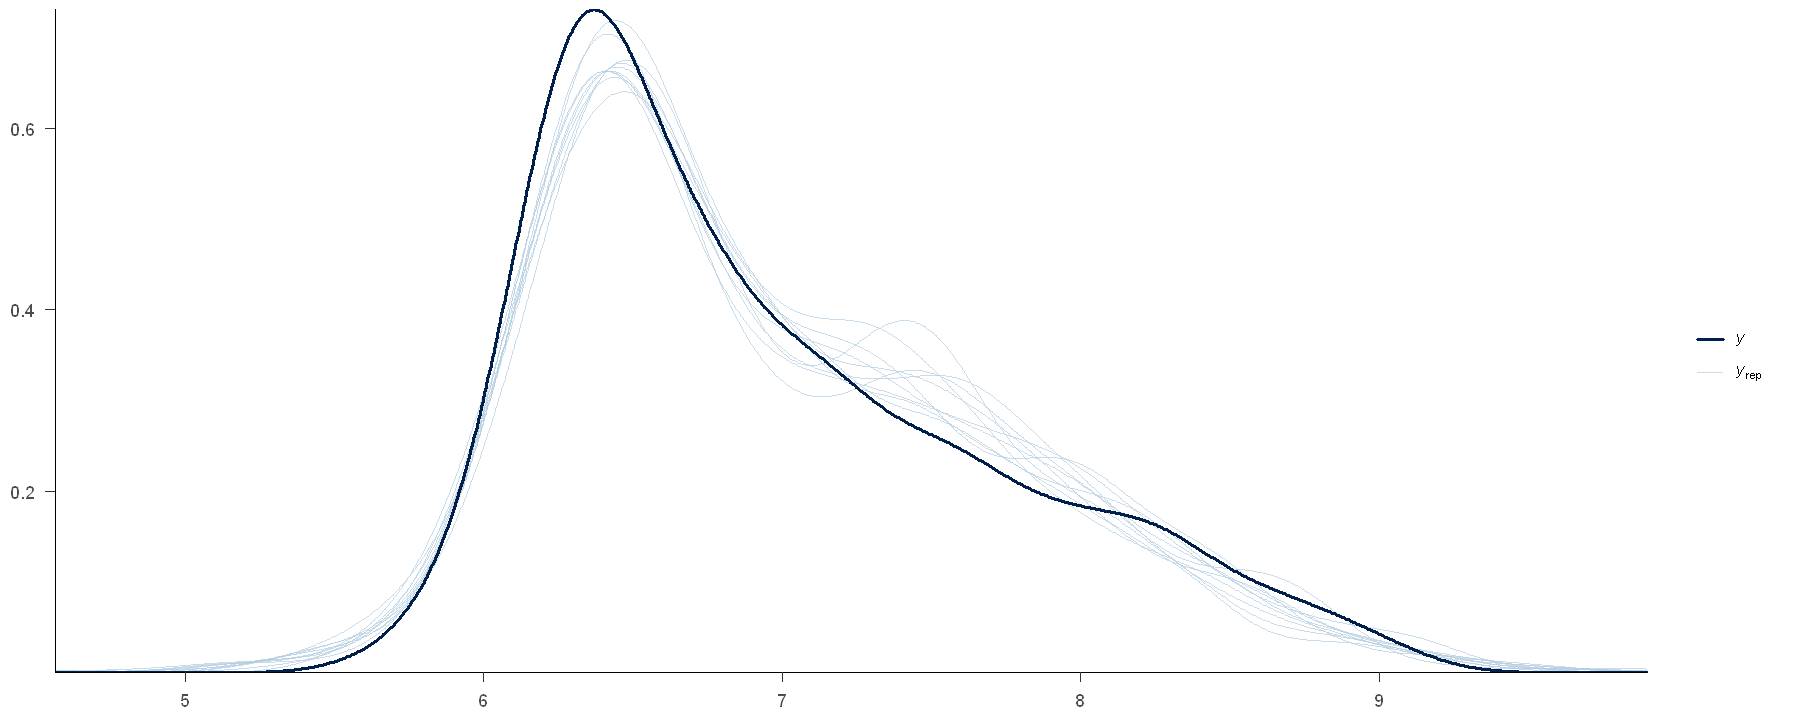

In [331]:
options(repr.plot.width = 15, repr.plot.height = 6)

bayesplot::pp_check(no_pooled_model) + 
papaja::theme_apa()

In [332]:
# 生成后验预测
ppc <- brms::posterior_predict(no_pooled_model)

# 调用函数计算HDI
no_hdi_sum <- ppc_sum(ppc, data = df_first5, y = "RT")

# 查看结果
head(no_hdi_sum)

,mean,sd,Q2.5,Q97.5,y,obs_id,subject
,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<fct>
1,6.868931,0.5614584,5.862821,8.073911,1465,1,66670
2,6.881217,0.5545996,5.784720,7.958921,1626,2,66670
3,6.871327,0.5447489,5.829130,7.934878,993,3,66670
4,6.887977,0.5448356,5.791339,7.933132,845,4,66670
5,6.871957,0.5449820,5.786703,7.912928,1760,5,66670
6,6.867720,0.5555832,5.786927,7.949444,1443,6,66670


进行对数转换：

In [333]:
no_hdi_sum <- inv_log_hdi_sum(no_hdi_sum)

### 非池化模型的缺点  

可以看到在非池化模型中，每个组的均值与方差都是不同的，非池化模型充分考虑了每个组内部的情况，然而，这种模型的缺点可能包括：  

1. 在小样本数据上，非池化模型存在过拟合的风险；  

2. 非池化模型假设每个组都属于不同的分布，因此其得出的结果难以用来预测新组别的情况。

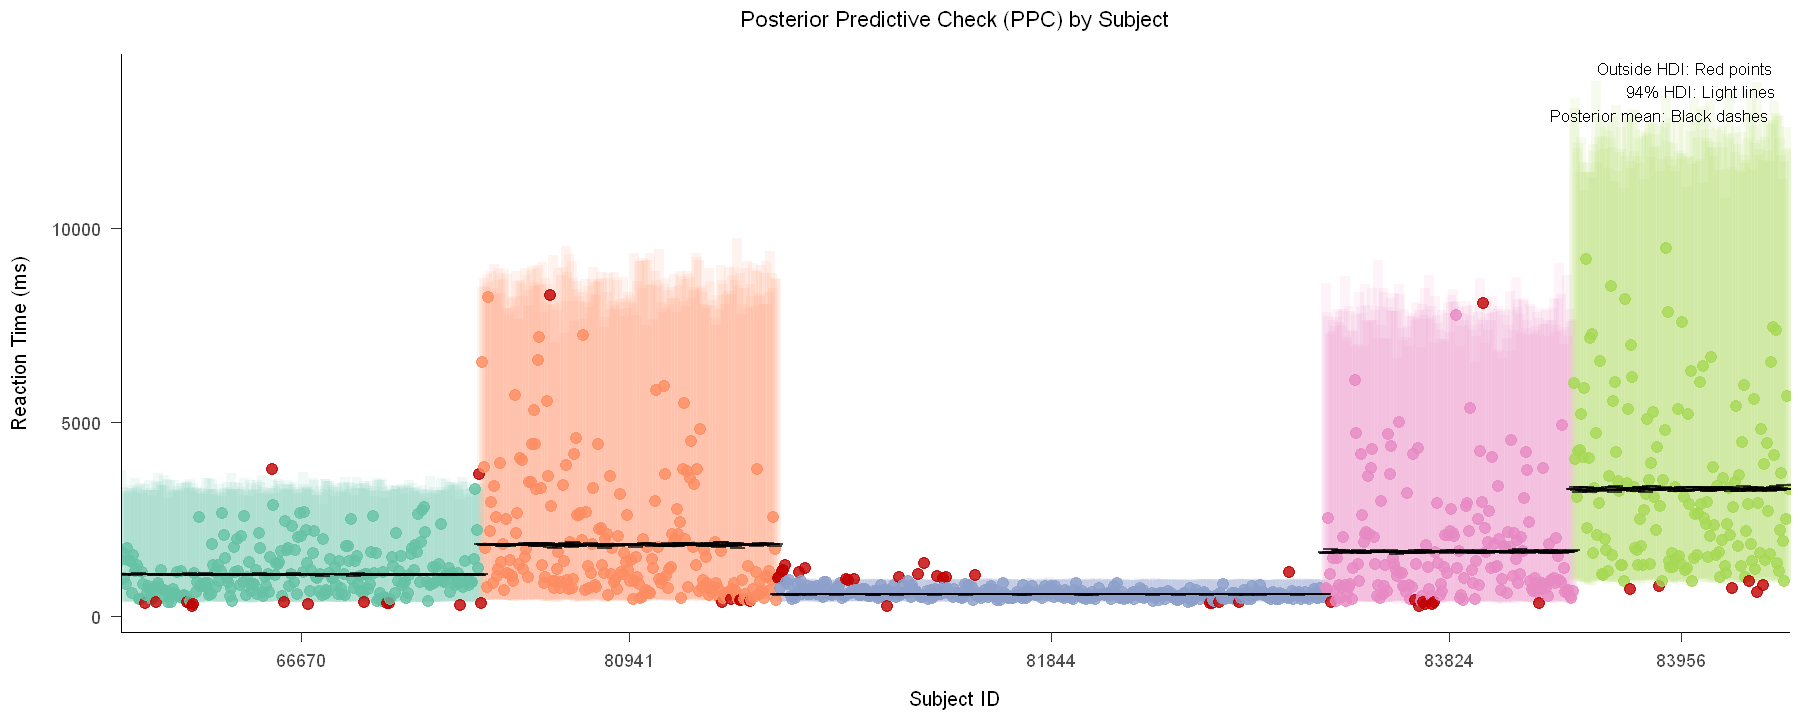

In [334]:
ppc_plot(hdi_sum=no_hdi_sum)

## Partial pooling  

- 完全池化模型仅考虑了trial之间的差异，没有考虑被试之间的差异。  
- 非池化模型考虑了被试的差异，但是容易受到不同被试内部极端数据的影响，忽视了不同被试做同一任务时可能存在的关系。  

部分池化 (Partial pooling)方法，是构建分层模型的关键。  
- 它假设，不同被试 (layer2) 来自于一个关于被试的总体 (Population)，被试形式的分布提供了对于组间变异(between variability)的解释。  
- 此外，不同trial的反应时  (layer1) 又来自于不同被试 (layer2) ，每个被试内部的trial数形成的分布提供了对于组内变异(within variability)的解释。  

![Image Name](https://cdn.kesci.com/upload/sooknhowtp.png?imageView2/0/w/960/h/960)


### 模型定义及MCMC采样  

层级模型的数学形式：  

$$  
\begin{array}{rll} 
\text{priors:} \;\; \;\; \;\; \;\; \mu  & \sim N(7.5, 5^2) & \\  
\sigma_y & \sim \text{Exp}(1)    & \\  
\sigma_\mu & \sim \text{Exp}(1)    & \\  
\mu_j | \mu, \sigma_\mu \stackrel{ind}{\sim} N(\mu, \sigma_\mu^2) \hspace{0.13in} & \text{(Layer2：被试水平)} \\  
\text{likelihood:} \;\; \;\; Y_{ij} | \mu_j, \sigma_y \sim N(\mu_j, \sigma_y^2) \hspace{0.05in} & \text{(Layer1：试次水平)} \\  
\end{array}  
$$

* $\mu_j$表示：第 $j$ 个被试的反应时间均值  

* $\sigma_\mu$表示：第 $j$ 个被试的反应时间标准差  


- 相对于非池化模型。部分池化模型的关键在于定义，被试参数在总体上的变异 
- 其次，是相似于非池化模型，trial数的反应时间分布在被试上的变异 

In [335]:
# 定义部分池化模型
partial_pooled_model <- brms::brm(
  log(RT) ~ 0 + (1|subject),
  data = df_first5,
  family = gaussian(),
  iter = 5000,
  warmup = 1000,
  chains = 4,
  cores = 4,
  seed = 84735,
  control = list(adapt_delta = 0.95)  # 提高采样稳定性
)

Compiling Stan program...

Start sampling



### 查看后验参数估计  

可以发现，  
- 不同被试的反应时间具有一致性，组内变异较小（较小的标准差）。  
- 被试均值存在显著差异，表明被试间的反应时间差异显著。

In [336]:
summary(partial_pooled_model)

 Family: gaussian 
  Links: mu = identity; sigma = identity 
Formula: log(RT) ~ 0 + (1 | subject) 
   Data: df_first5 (Number of observations: 1142) 
  Draws: 4 chains, each with iter = 5000; warmup = 1000; thin = 1;
         total post-warmup draws = 16000

Multilevel Hyperparameters:
~subject (Number of levels: 5) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     6.94      2.12     4.07    12.22 1.00     1047     1262

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     0.57      0.01     0.55     0.60 1.00     2784     3004

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at convergence, Rhat = 1).

In [337]:
subject_mu <- brms::ranef(partial_pooled_model)$subject[, , "Intercept"]

hyperparams <- brms::VarCorr(partial_pooled_model)

cat("=== 每个被试的均值 ===\n")
print(subject_mu)
cat("\n=== 超参数 ===\n")
print(hyperparams)

=== 每个被试的均值 ===
      Estimate  Est.Error     Q2.5    Q97.5
66670 6.871592 0.03621978 6.800585 6.942638
80941 7.251841 0.04037106 7.172379 7.331122
81844 6.382620 0.02957197 6.324621 6.440689
83824 7.146933 0.04419094 7.061307 7.233163
83956 7.884404 0.04697767 7.792310 7.976389

=== 超参数 ===
$subject
$subject$sd
          Estimate Est.Error     Q2.5    Q97.5
Intercept 6.935755  2.124756 4.067314 12.22377


$residual__
$residual__$sd
  Estimate  Est.Error      Q2.5     Q97.5
 0.5733808 0.01196794 0.5510012 0.5968895




In [171]:
# post_samples <- brms::posterior_samples(partial_pooled_model)
# # 查看完整参数名
# print(colnames(post_samples))

[1] "sd_subject__Intercept"      "sigma"                     
[3] "r_subject[66670,Intercept]" "r_subject[80941,Intercept]"
[5] "r_subject[81844,Intercept]" "r_subject[83824,Intercept]"
[7] "r_subject[83956,Intercept]" "lprior"                    
[9] "lp__"                      


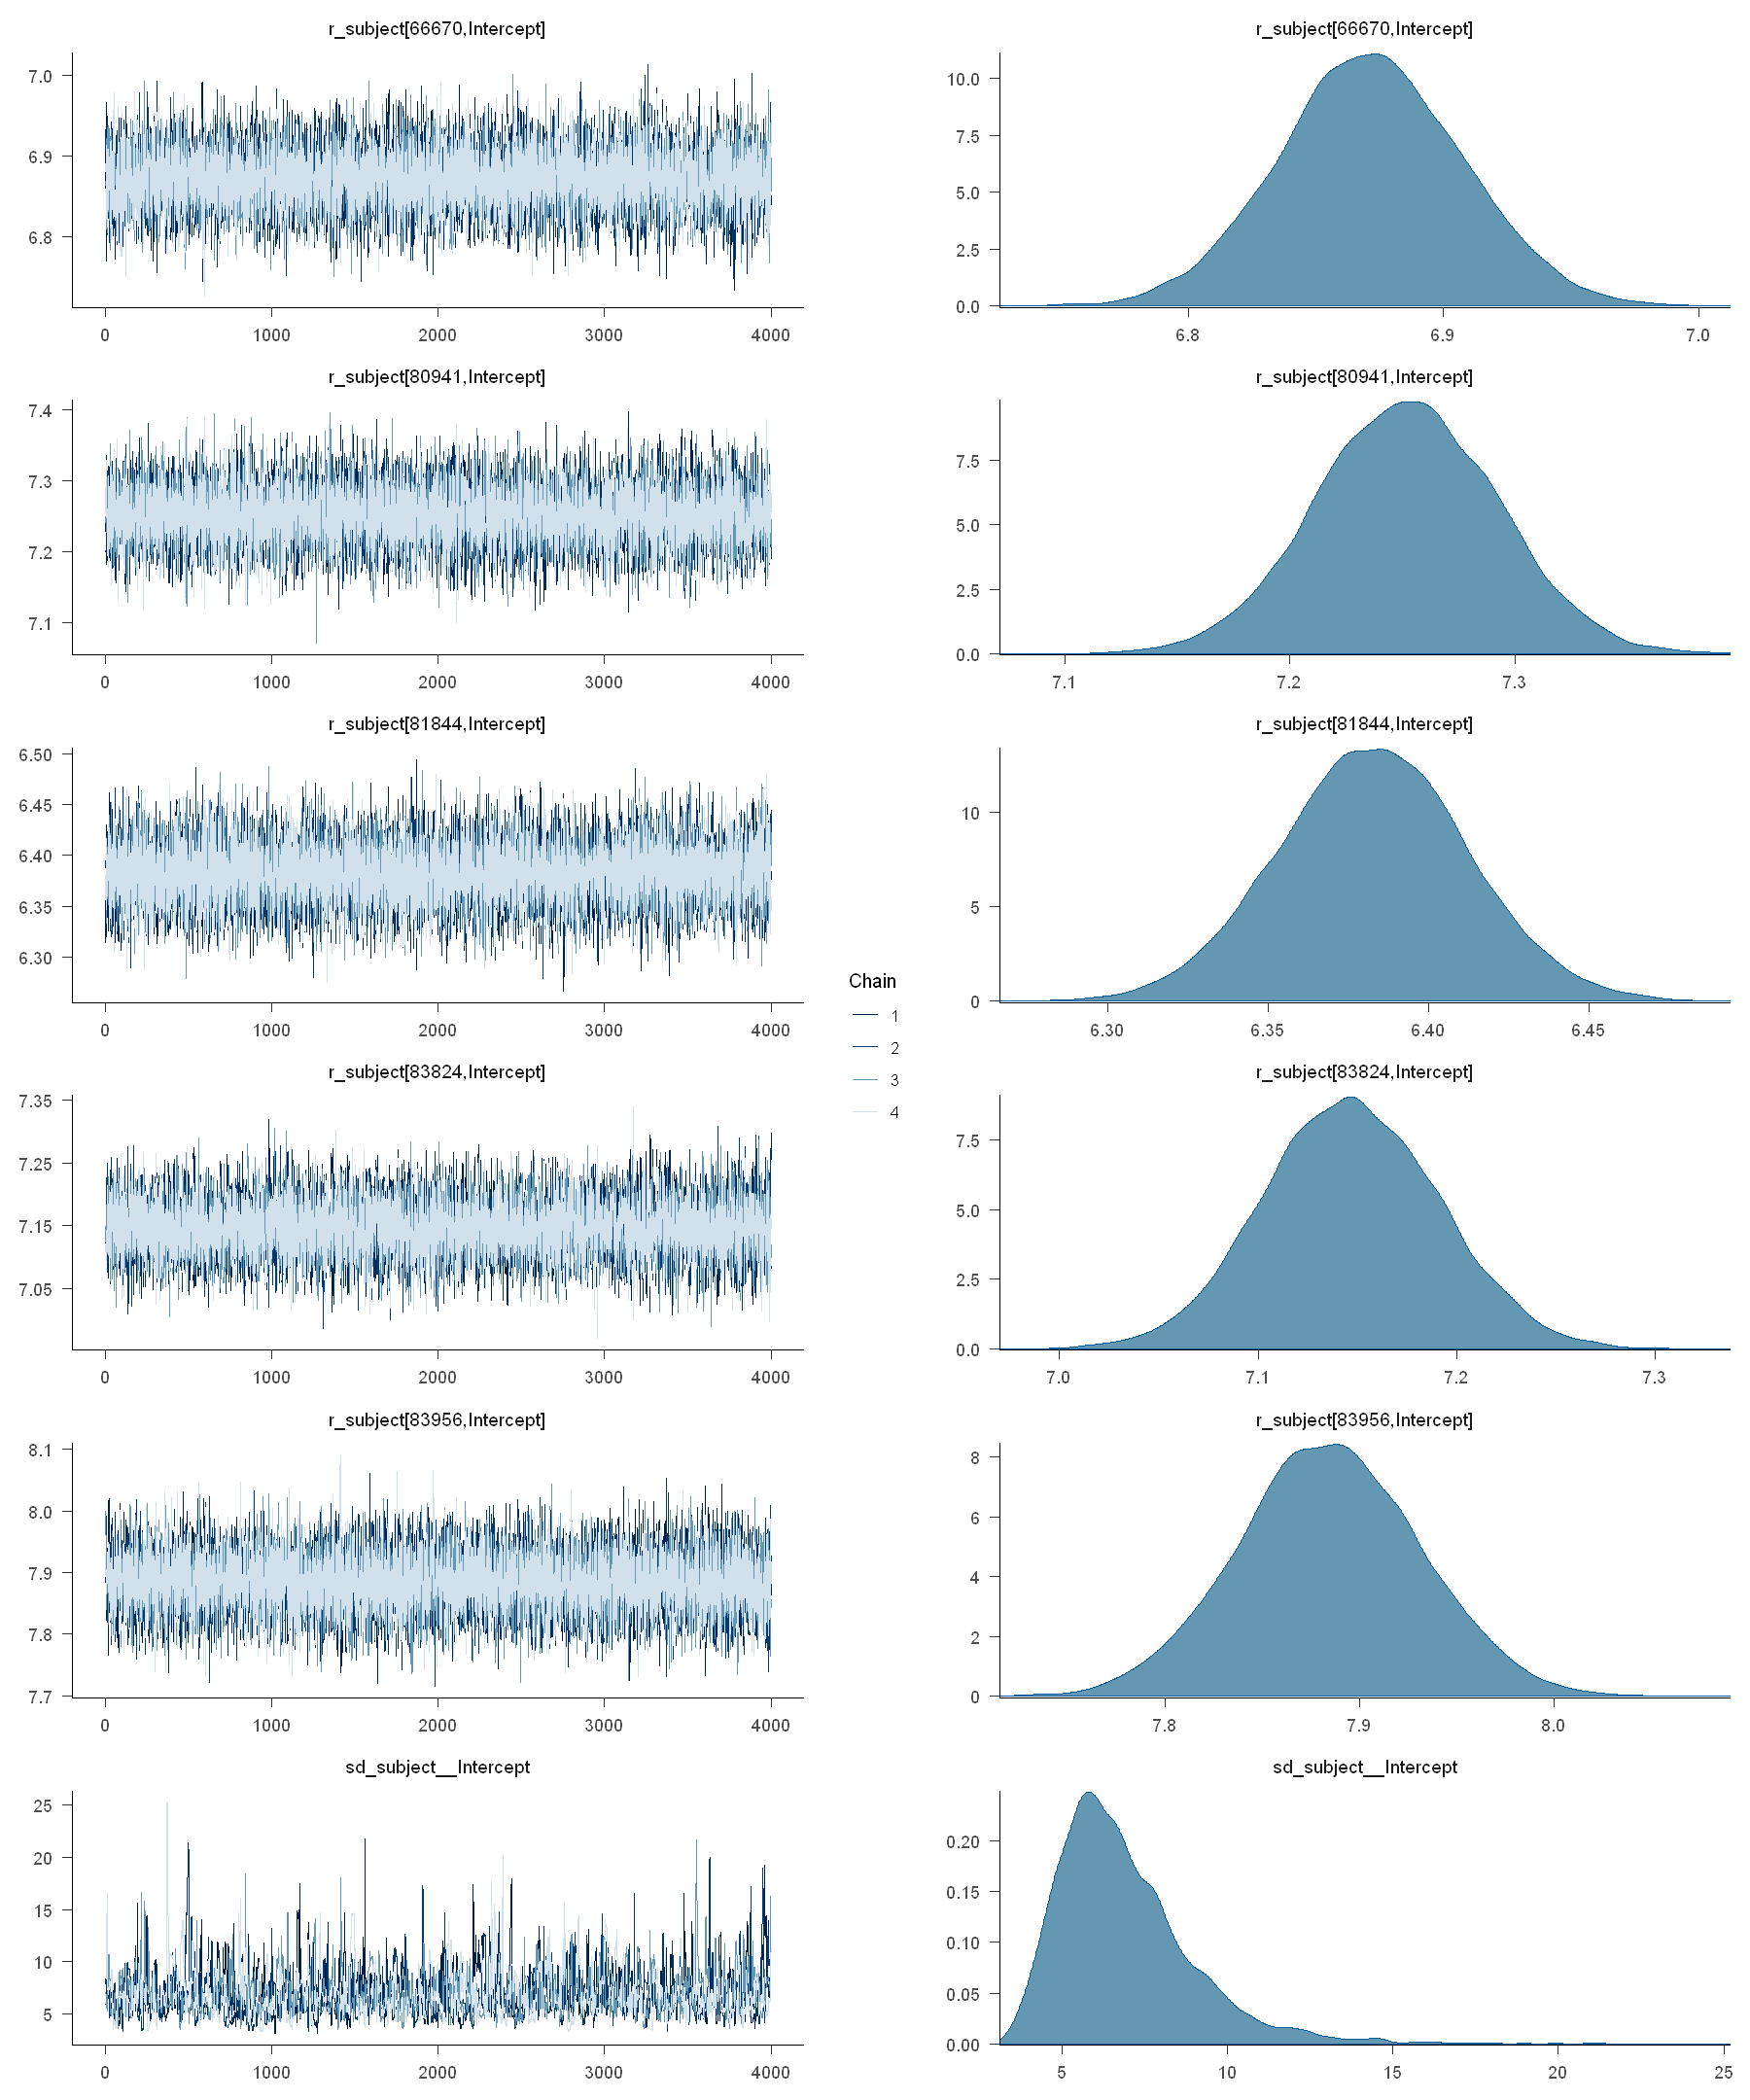

In [338]:
options(repr.plot.width = 15, repr.plot.height = 18)

# 从 brms 模型中提取后验样本
posterior_samples <- as.array(partial_pooled_model)

target_pars <- c(
  # 每个被试的均值（随机截距）
  "r_subject[66670,Intercept]",
  "r_subject[80941,Intercept]",
  "r_subject[81844,Intercept]",
  "r_subject[83824,Intercept]",
  "r_subject[83956,Intercept]",
  "sd_subject__Intercept"
)

# 绘制迹图
trace_plot <- bayesplot::mcmc_trace(
  posterior_samples,
  pars = target_pars,
  facet_args = list(nrow = 6, ncol = 1)
) +
  papaja::theme_apa()

# 绘制后验分布图
dens_plot <- bayesplot::mcmc_dens(
  posterior_samples,
  pars = target_pars,
  facet_args = list(nrow = 6, ncol = 1)
) +
  papaja::theme_apa()

# 组合图形
trace_plot + dens_plot

### 后验预测分布  

* 可以看到相比于非池化模型，在层级模型中不同组的后验预测可信区间的长度、后验预测均值都更为接近

Using 10 posterior draws for ppc type 'dens_overlay' by default.



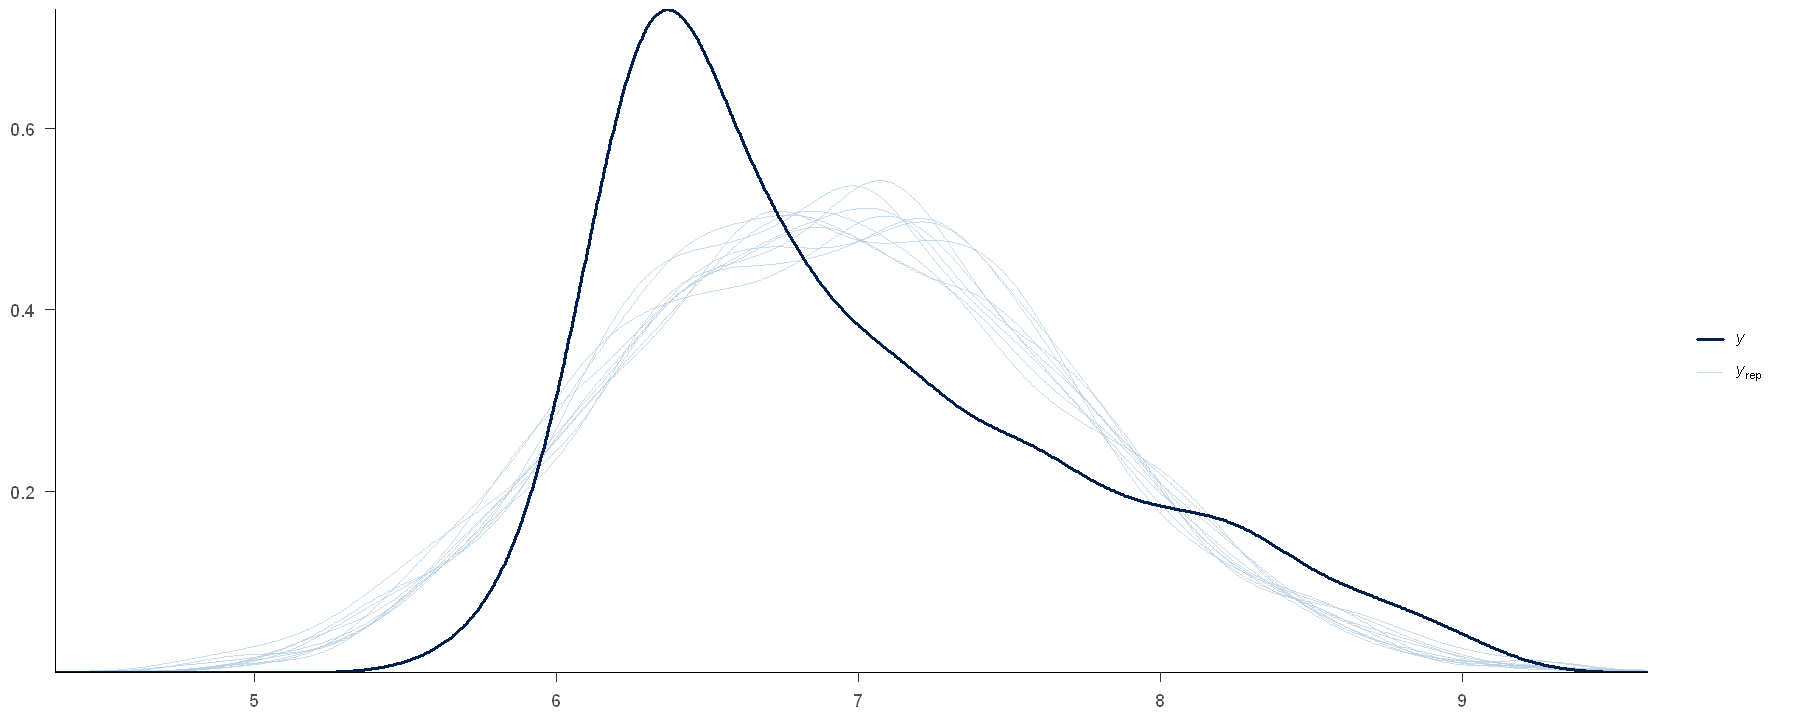

In [339]:
options(repr.plot.width = 15, repr.plot.height = 6)
bayesplot::pp_check(partial_pooled_model) +
papaja::theme_apa()

同样进行对数转换：

In [340]:
ppc <- brms::posterior_predict(partial_pooled_model)
partial_hdi_sum <- ppc_sum(ppc, data = df_first5, y = "RT")
partial_hdi_sum <- inv_log_hdi_sum(partial_hdi_sum)

可视化预测结果：

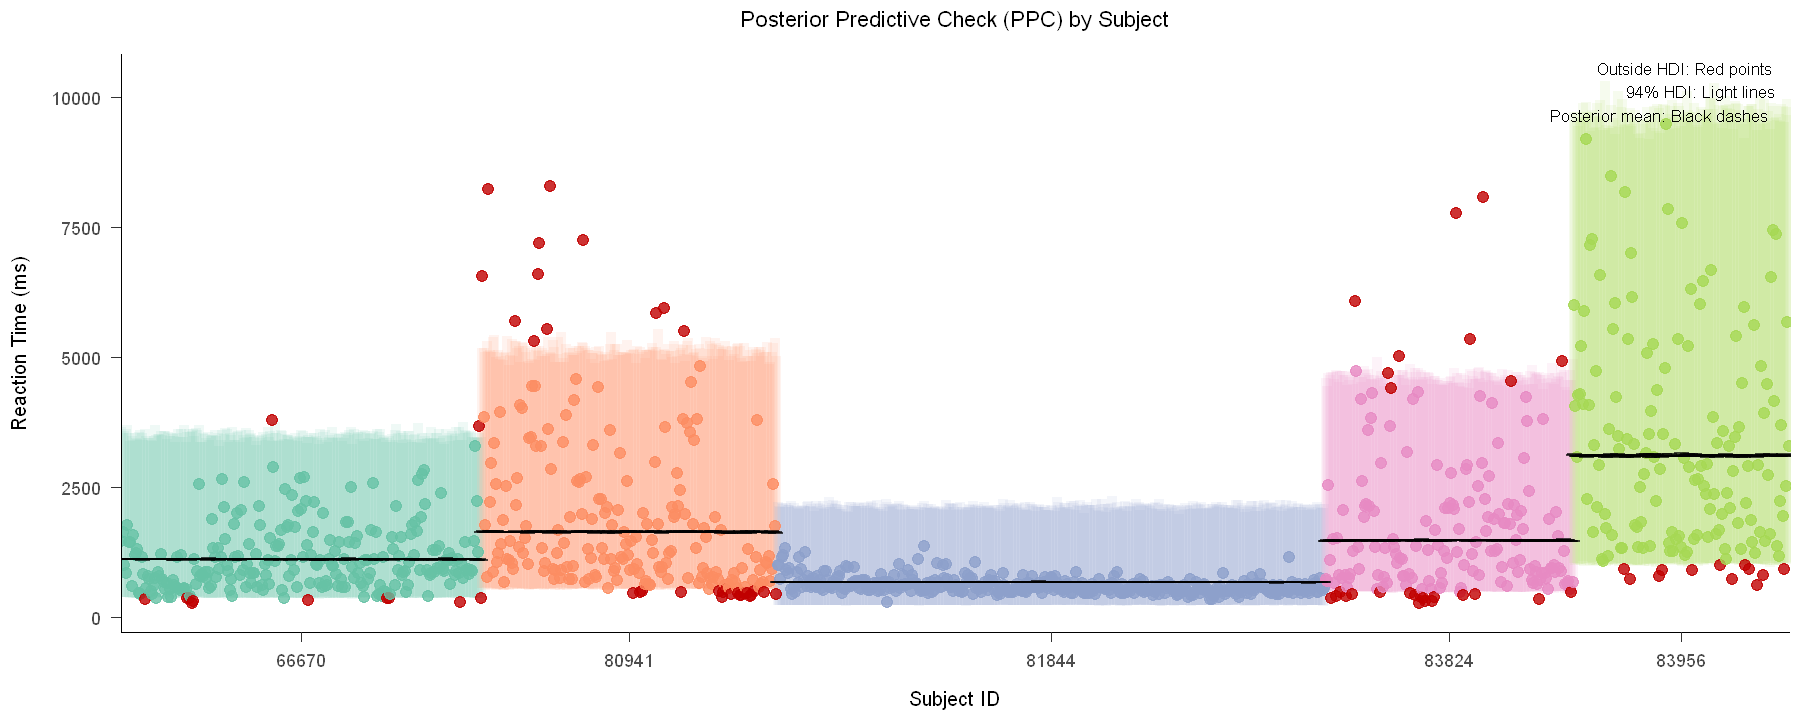

In [341]:
ppc_plot(hdi_sum=partial_hdi_sum)

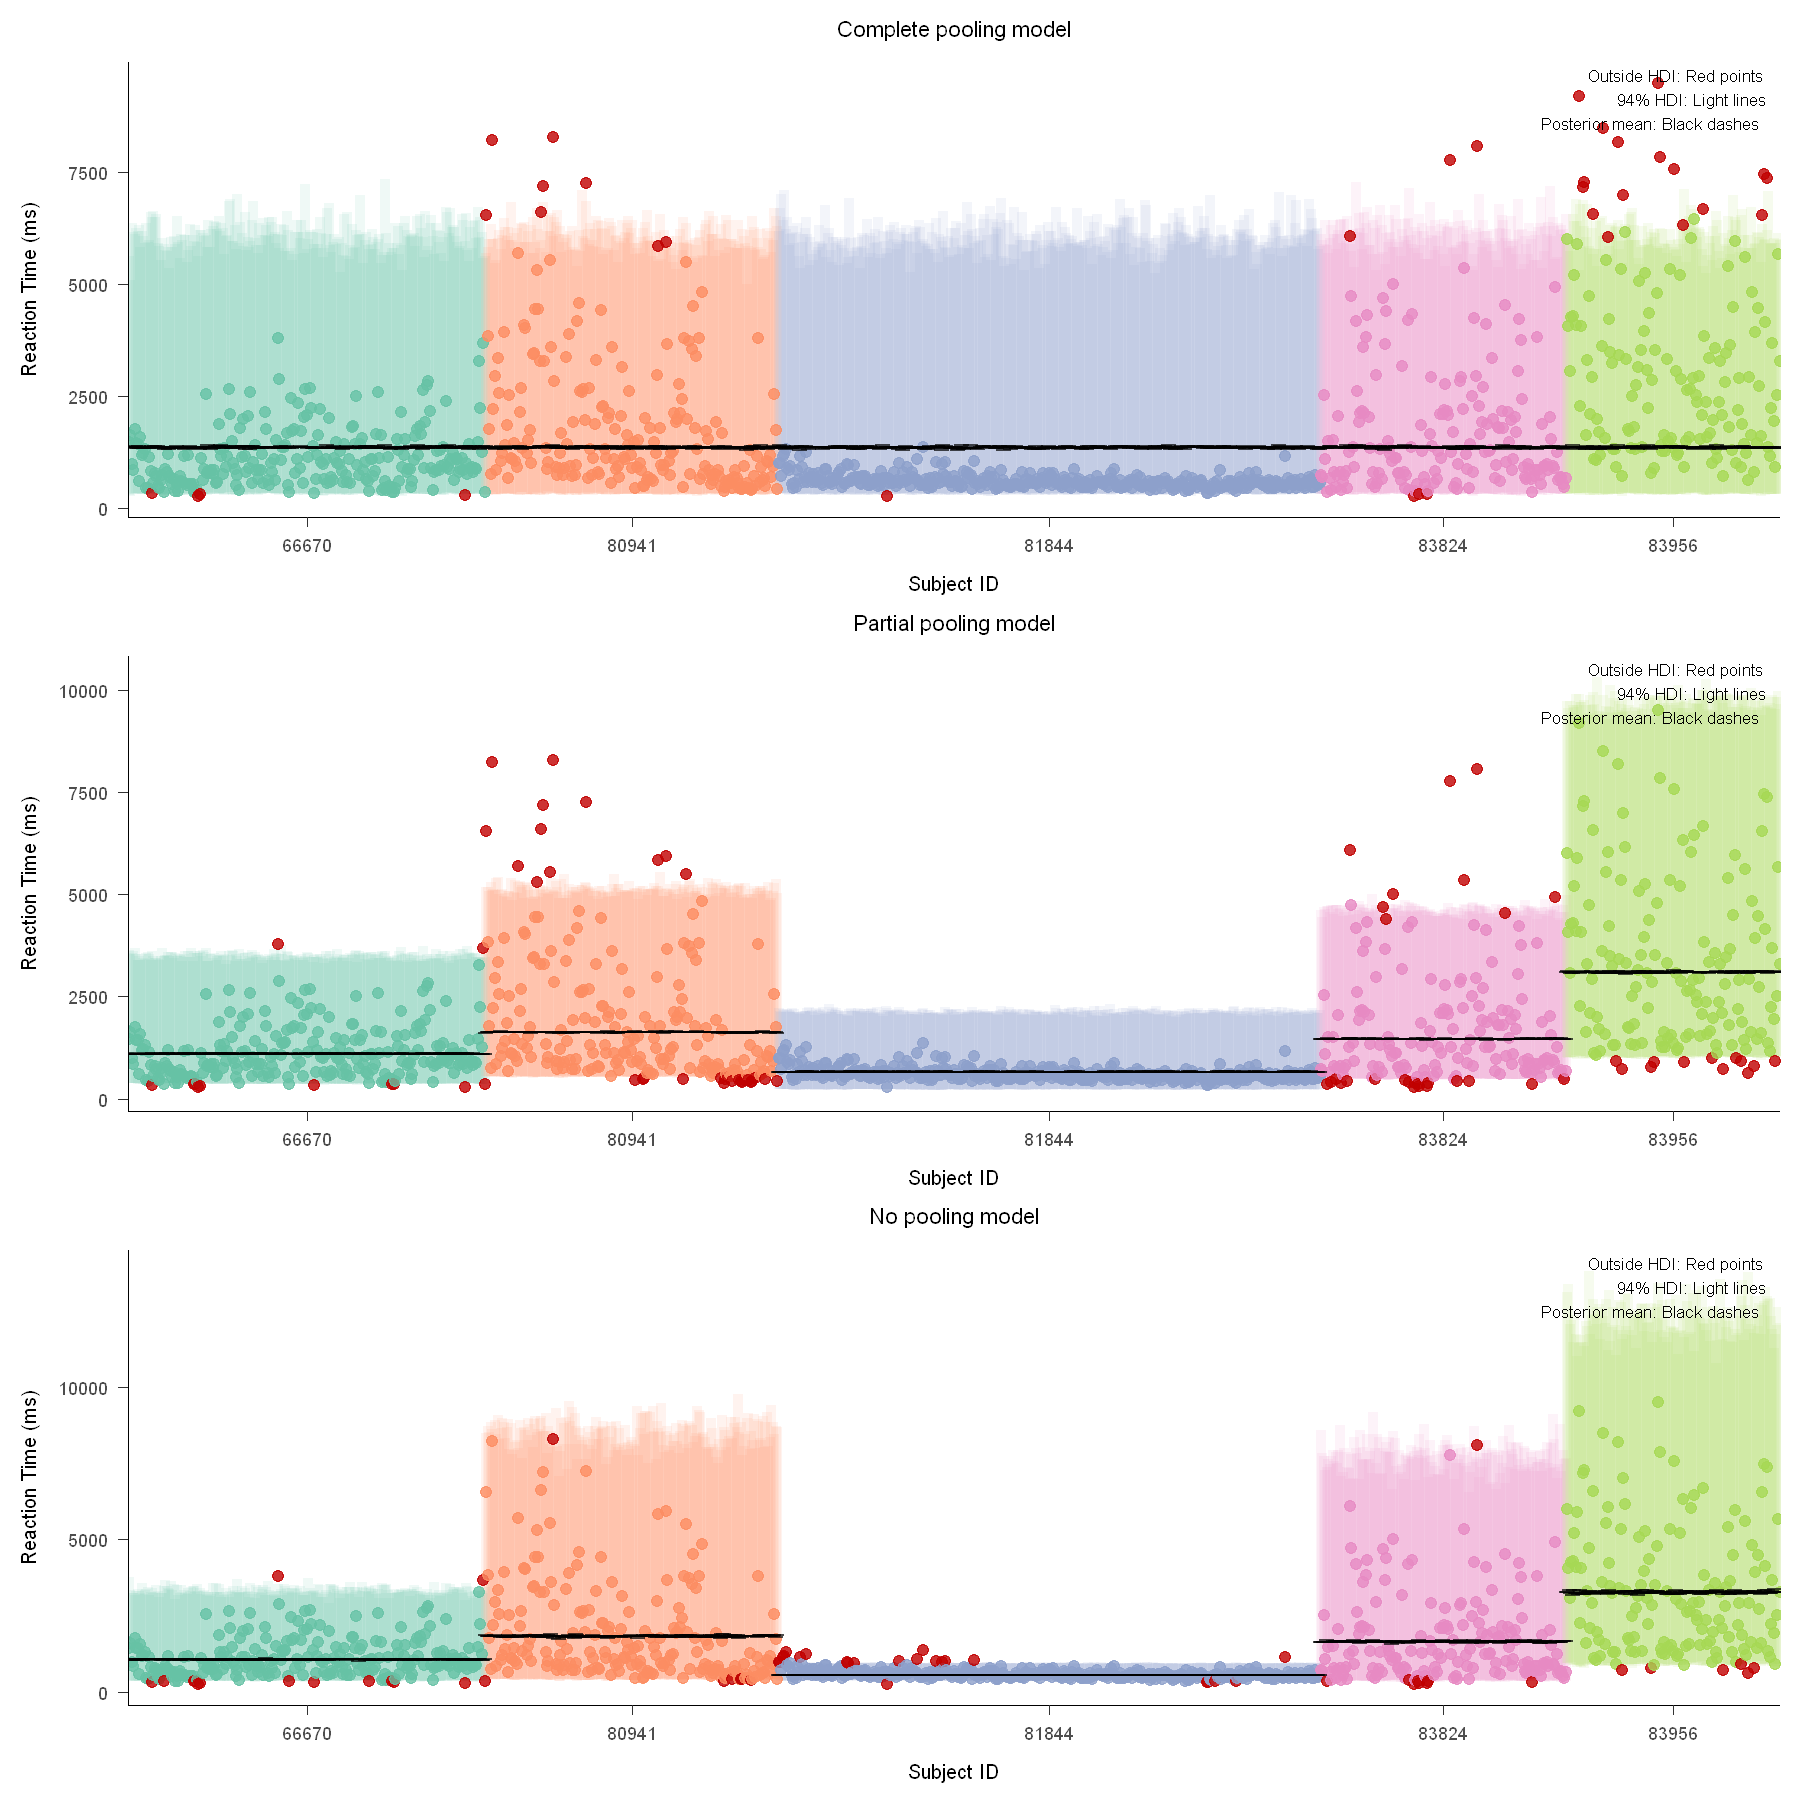

In [342]:
options(repr.plot.width = 15, repr.plot.height = 15)

p1 <- ppc_plot(hdi_sum = complete_hdi_sum, show_plot = FALSE) +
  ggplot2::ggtitle("Complete pooling model") +
  papaja::theme_apa()

p2 <- ppc_plot(hdi_sum = partial_hdi_sum, show_plot = FALSE) +
  ggplot2::ggtitle("Partial pooling model") +
  papaja::theme_apa()


p3 <- ppc_plot(hdi_sum = no_hdi_sum, show_plot = FALSE) +
  ggplot2::ggtitle("No pooling model") +
  papaja::theme_apa()

p1 / p2 / p3

## Within- vs between-group variability  

* 在完全池化模型中，变异性的来源只有一种，即个体观测值 $Y$ 在总体中的变异  ($\sigma$)  
* 在非池化模型中，变异来源分散在不同被试中，即个体观测值在不同被试中的变异 ($\sigma_j$)  

在部分池化模型中，我们可以把个体观测值$Y$的变异来源分解成两个部分：  
* 组内变异 $\sigma_y^2$  
* 组间变异 $\sigma_{\mu}^2$  

$$  
\text{Var}(Y_{ij}) = \sigma_y^2 + \sigma_{\mu}^2  
$$  

<div align="center">
  <img src="https://cdn.kesci.com/upload/sopzqb1xl1.png?imageView2/0/w/960/h/960" alt="Image">
</div>

类似于单因素方差分析  

$$  
\begin{split}  
\frac{\sigma^2_y}{\sigma^2_\mu + \sigma^2_y}  
& = \text{ $\text{Var}(Y_{ij})$ 可以被组内方差解释的部分} \\  
\frac{\sigma^2_\mu}{\sigma^2_\mu + \sigma^2_y}  
& = \text{$\text{Var}(Y_{ij})$ 可以被组间方差解释的部分} \\  
\end{split}  
$$  


* 组间方差远大于组内方差($\sigma_\mu > \sigma_y$)，那么组间方差可以解释大部分观测值的变异  
* 组间方差远小于组内方差($\sigma_\mu < \sigma_y$)，那么组与组之间的区别就不是很明显


* 此外，若组间方差远大于组内方差，则可以说明组内的变异性很小，组内分数高度相关  

$$  
\text{Cor}(Y_{ij}, Y_{kj}) = \frac{\sigma^2_\mu}{\sigma^2_\mu + \sigma^2_y}  
$$  

* 下图展示了三种组间方差与组内方差的分布情况(横轴为方差的大小，蓝色为组间方差，黑色为组内方差)  


![Image Name](https://cdn.kesci.com/upload/s5k6q39qp6.png?imageView2/0/w/700)  


- 组别越独特，$\sigma_{\mu}$ 相对越大，每**组内的相关性就越大**。  
- 图 (a) 中，组间变异是组内变异的4倍，此时组内相关性为 0.8，接近于 1。  
- 图 (c) 中，组间变异是组内变异的1/4倍，组内相关性为 0.2，接近 0。

我们可以先总结后验参数估计的情况，并计算组间组内变异和相关性

进行对数转换：

## Shrinkage & the bias-variance trade-off  

从下图和表格中可以发现，三个模型的关系：  
* 部分池化模型的超参数 (hyper_mu)的后验分布接近完全池化模型估计的参数 (mu)  
* 部分池化模型中对被试参数的估计 (mu[?]) 的后验分布接近非池化模型估计的参数 (mu[?])  
* 对于目前的被试来说，相比于非池化模型，部分池化模型中的参数 (mu[?]) 更加靠近完全池化模型，这就是**分层模型的收缩 (shrinkage) 现象**。  

In [361]:
# 定义转换函数
inv_log_hdi_sum <- function(posterior_stats) {
  posterior_stats %>%
    dplyr::mutate(
      # 对所有数值列进行指数转换（逆对数）
      dplyr::across(where(is.numeric), exp)
    )
}

# 通用统计量计算函数
summarise_param <- function(data) {
  data %>%
    dplyr::summarise(
      mean = mean(value),
      sd = sd(value),
      q5 = quantile(value, 0.05),
      q95 = quantile(value, 0.95)
    )
}

In [349]:
# 提取模型参数
# ========== 完全池化模型========== 
complete_stats <- complete_pooled_model %>%
  # 提取截距（mu）
  tidybayes::spread_draws(Intercept) %>%  
  dplyr::rename(value = Intercept) %>%
  dplyr::mutate(
    param_type = "mu",
    subject = "All subjects"
  ) %>%
  summarise_param() %>%  # 通用统计函数
  inv_log_hdi_sum() %>%  # 逆对数转换
  dplyr::mutate(
    source = "Complete pool",
    param_type = "mu",
    subject = "All subjects"
  )

# ========== 部分池化模型 ==========
# 提取被试水平mu参数
partial_mu_stats <- partial_pooled_model %>%
  tidybayes::spread_draws(r_subject[subject_idx, Intercept]) %>%
  dplyr::rename(value = r_subject) %>%
  dplyr::mutate(
    param_type = "mu",
    subject = paste0("Subject_", subject_idx)
  ) %>%
  dplyr::group_by(subject) %>%
  summarise_param() %>% 
  inv_log_hdi_sum() %>%
  dplyr::mutate(
    source = "Partial pool",
    param_type = "mu"
  )

# 提取超参数sd_subject__Intercept
partial_hyper_stats <- partial_pooled_model %>%
  tidybayes::spread_draws(sd_subject__Intercept) %>%
  dplyr::rename(value = sd_subject__Intercept) %>%
  dplyr::mutate(
    param_type = "sd_subject__Intercept",  # 标记参数类型
    subject = "All subjects"  # 超参数属于全局（All subjects）
  ) %>%
  summarise_param() %>%
  inv_log_hdi_sum() %>%
  dplyr::mutate(
    source = "Partial pool",
    param_type = "mu",
    subject = "All subjects"
  )

# 合并部分池化模型的mu + 超参数
partial_stats <- dplyr::bind_rows(partial_mu_stats, partial_hyper_stats)

# ========== 无池化模型 ==========
no_stats <- no_pooled_model %>%
  tidybayes::gather_draws(`b_subject[0-9]+`, regex = TRUE) %>%
  dplyr::mutate(
    value = .value,
    param_type = "mu",
    subject = gsub("b_subject", "", .variable)
  ) %>%
  dplyr::group_by(subject) %>%
  summarise_param() %>%  # 通用统计函数
  inv_log_hdi_sum() %>%
  dplyr::mutate(
    source = "No pool",
    param_type = "mu"
  )

# ========== 合并所有结果 ==========
df_compare <- dplyr::bind_rows(
  complete_stats, partial_stats, no_stats) %>%
  dplyr::arrange(source, param_type, subject) %>%
  dplyr::select(
    source, param_type, subject,
    mean, sd, q5, q95
  )

print(df_compare)

# A tibble: 12 × 7
   source        param_type subject        mean    sd     q5    q95
   <chr>         <chr>      <chr>         <dbl> <dbl>  <dbl>  <dbl>
 1 Complete pool mu         All subjects  1044.  1.02 1009.   1081.
 2 No pool       mu         66670          964.  1.04  911.   1023.
 3 No pool       mu         80941         1410.  1.05 1289.   1540.
 4 No pool       mu         81844          592.  1.01  580.    603.
 5 No pool       mu         83824         1271.  1.06 1154.   1400.
 6 No pool       mu         83956         2662.  1.06 2433.   2918.
 7 Partial pool  mu         All subjects  1028.  8.37   77.4 48053.
 8 Partial pool  mu         Subject_66670  964.  1.04  909.   1024.
 9 Partial pool  mu         Subject_80941 1411.  1.04 1320.   1507.
10 Partial pool  mu         Subject_81844  591.  1.03  563.    621.
11 Partial pool  mu         Subject_83824 1270.  1.05 1182.   1367.
12 Partial pool  mu         Subject_83956 2656.  1.05 2458.   2871.


In [353]:
# 提取模型参数
summarise_mu <- function(data) {
  data %>%
    dplyr::summarise(
      mean = mean(mu),
      lower = quantile(mu, 0.025),
      upper = quantile(mu, 0.975)
    )
}

# 提取完全池化模型
complete_mu <- complete_pooled_model %>%
  tidybayes::spread_draws(Intercept) %>%
  dplyr::rename(mu = Intercept) %>%
  summarise_mu() %>%
  dplyr::mutate(
    subject = "All subjects",
    model = "Complete Pooling"
  )

# 提取部分池化模型
partial_mu <- partial_pooled_model %>%
  tidybayes::spread_draws(r_subject[subject_idx, Intercept]) %>%
  dplyr::rename(mu = r_subject) %>%
  dplyr::mutate(subject = paste0("Subject_", subject_idx)) %>%
  dplyr::group_by(subject) %>%
  summarise_mu() %>%
  dplyr::mutate(model = "Partial Pooling")

partial_hyper <- partial_pooled_model %>%
  tidybayes::spread_draws(sd_subject__Intercept) %>%
  dplyr::rename(mu = sd_subject__Intercept) %>%
  summarise_mu() %>%
  dplyr::mutate(
    subject = "hyper_mu",
    model = "Partial Pooling",
  )

# 提取无池化模型
no_mu <- no_pooled_model %>%
  tidybayes::gather_draws(`b_subject[0-9]+`, regex = TRUE) %>%
  dplyr::mutate(subject = paste0("Subject_", gsub("b_subject", "", .variable))) %>%  # 统一被试名称格式
  dplyr::rename(mu = .value) %>%
  dplyr::group_by(subject) %>%
  summarise_mu() %>%
  dplyr::mutate(model = "No Pooling")

# 合并所有数据，统一被试顺序
all_subjects <- c(partial_mu$subject, "All subjects", "hyper_mu") %>% unique()  # 包含所有被试+完全池化的"All subjects"
all_mu <- dplyr::bind_rows(partial_mu, partial_hyper, no_mu, complete_mu) %>%
  dplyr::mutate(subject = factor(subject, levels = all_subjects))  # 统一被试顺序

all_mu

subject,mean,lower,upper,model
<fct>,<dbl>,<dbl>,<dbl>,<chr>
Subject_66670,6.871592,6.800585,6.942638,Partial Pooling
Subject_80941,7.251841,7.172379,7.331122,Partial Pooling
Subject_81844,6.382620,6.324621,6.440689,Partial Pooling
Subject_83824,7.146933,7.061307,7.233163,Partial Pooling
Subject_83956,7.884404,7.792310,7.976389,Partial Pooling
hyper_mu,6.935755,4.067314,12.223769,Partial Pooling
Subject_66670,6.871532,6.802694,6.939370,No Pooling
Subject_80941,7.251366,7.144116,7.354245,No Pooling
Subject_81844,6.382751,6.359345,6.406064,No Pooling


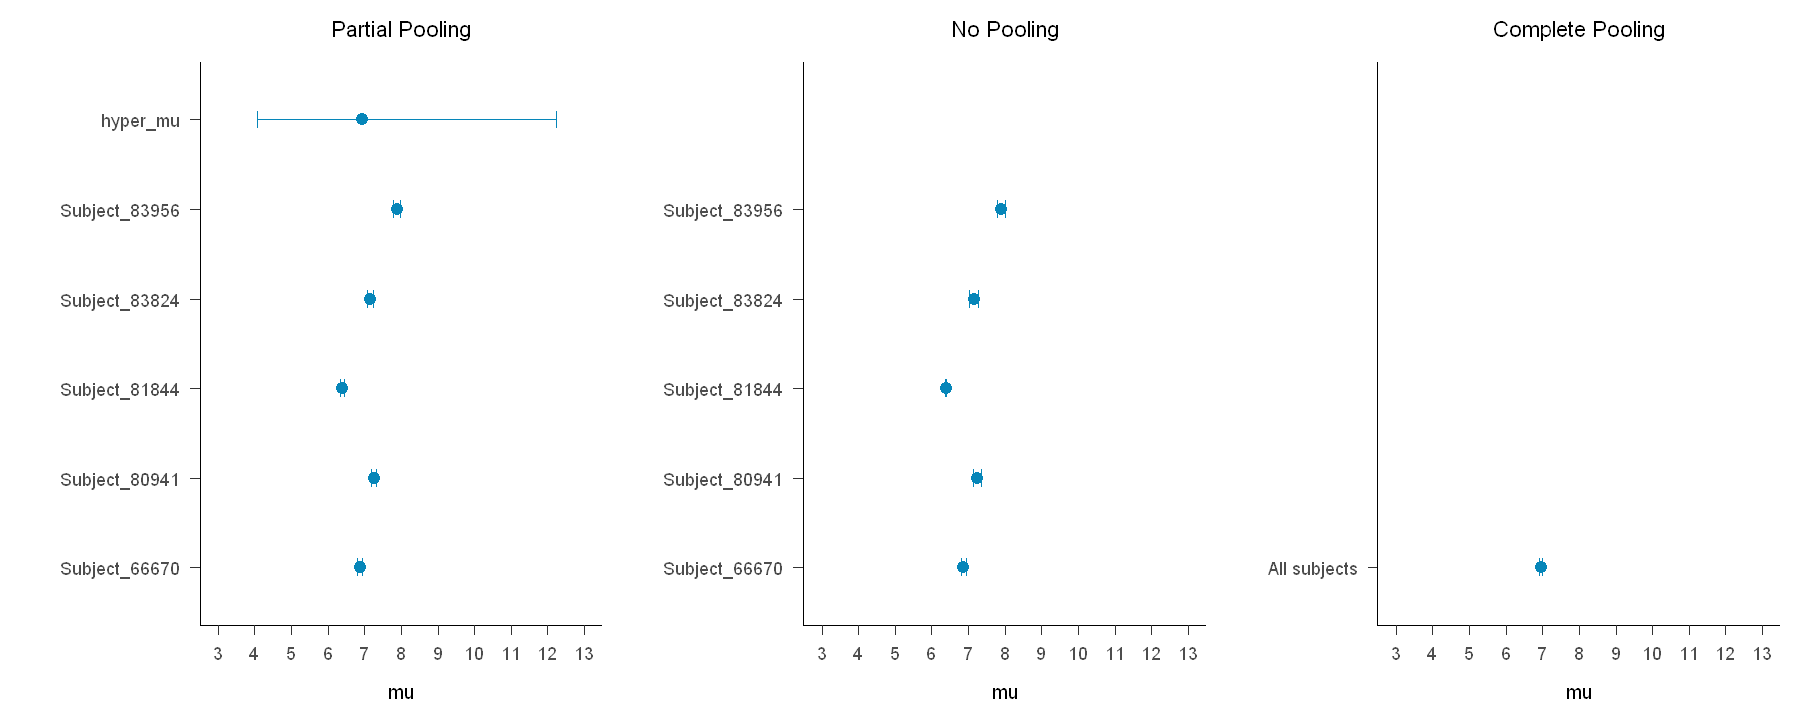

In [363]:
#  计算最大索引（即被试数量）
max_index <- all_mu %>% 
  dplyr::filter(model != "Complete Pooling") %>% 
  dplyr::pull(subject) %>% 
  unique() %>% 
  length()

# --------------------------
# 绘制森林图
# --------------------------
options(repr.plot.width = 15, repr.plot.height = 6)
plot_forest_ggplot <- function(data, title, max_index) { 
  data <- data %>%
    dplyr::arrange(subject) %>%  # 按统一的被试顺序排列
    dplyr::mutate(index = dplyr::row_number())
  ggplot2::ggplot(data, ggplot2::aes(y = index, x = mean, xmin = lower, xmax = upper)) +
    ggplot2::geom_point(size = 3, color = "#0686b9") +
    ggplot2::geom_errorbarh(height = 0.2, color = "#0686b9") +
    ggplot2::geom_vline(xintercept = 0, linetype = "dashed", color = "gray50") +
    ggplot2::scale_y_continuous(
      name = "", breaks = data$index, labels = data$subject, expand = c(0.02, 0.02),
      limits = c(0.5, max_index + 0.5)  # 强制y轴范围和前两个图一致，增加0.5的边距使点居中
    ) +
    ggplot2::scale_x_continuous(
      name = "mu", limits = c(3, 13), breaks = seq(3, 13, by = 1)
    ) +
    ggplot2::labs(title = title) +
    papaja::theme_apa()
}

p1 <- all_mu %>% 
  dplyr::filter(model == "Partial Pooling") %>% 
  plot_forest_ggplot("Partial Pooling", max_index) 

p2 <- all_mu %>% 
  dplyr::filter(model == "No Pooling") %>% 
  plot_forest_ggplot("No Pooling", max_index)

p3 <- all_mu %>% 
  dplyr::filter(model == "Complete Pooling") %>% 
  plot_forest_ggplot("Complete Pooling", max_index)

p1 + p2 + p3

* 在完全池化模型中，对于每一个被试来说，后验估计均值都是相同的，在弱先验的情况下，后验估计均值约等于所有观测值的平均值  
$$  
\overline{y}_{\text{global}} = \frac{1}{n}\sum_{\text{all } i,j }y_{ij}  
$$  

* 在非池化模型中，对于每一个被试来说，其后验估计均值的估计只来自该组内部，在弱先验的情况下，后验估计均值约等于该组内所有观测值的平均值  
$$  
\overline{y}_j = \frac{1}{n_j}\sum_{i=1}^{n_j} y_{ij}  
$$  

* 在层级模型中，后验估计均值则是在完全池化和非池化模型中找到一个平衡，组间(group-specific)参数有可能更倾向完全池化模型，也有可能更倾向于非池化模型，这种现象被称为shrinkage  
> 当使用弱信息先验时，分层模型的后验平均预测结果（大致）是完全池化模型和非池化模型预测结果的加权平均  
$$  
\frac{\sigma^2_y}{\sigma^2_y + n_j \sigma^2_\mu} \overline{y}_{\text{global}} + \frac{n_j\sigma^2_\mu}{\sigma^2_y + n_j \sigma^2_\mu} \overline{y}_j  
$$  

* 我们可以分别绘制出每个观测值对应的后验预测均值，并观察这些后验预测均值在不同的模型之间发生了什么变化

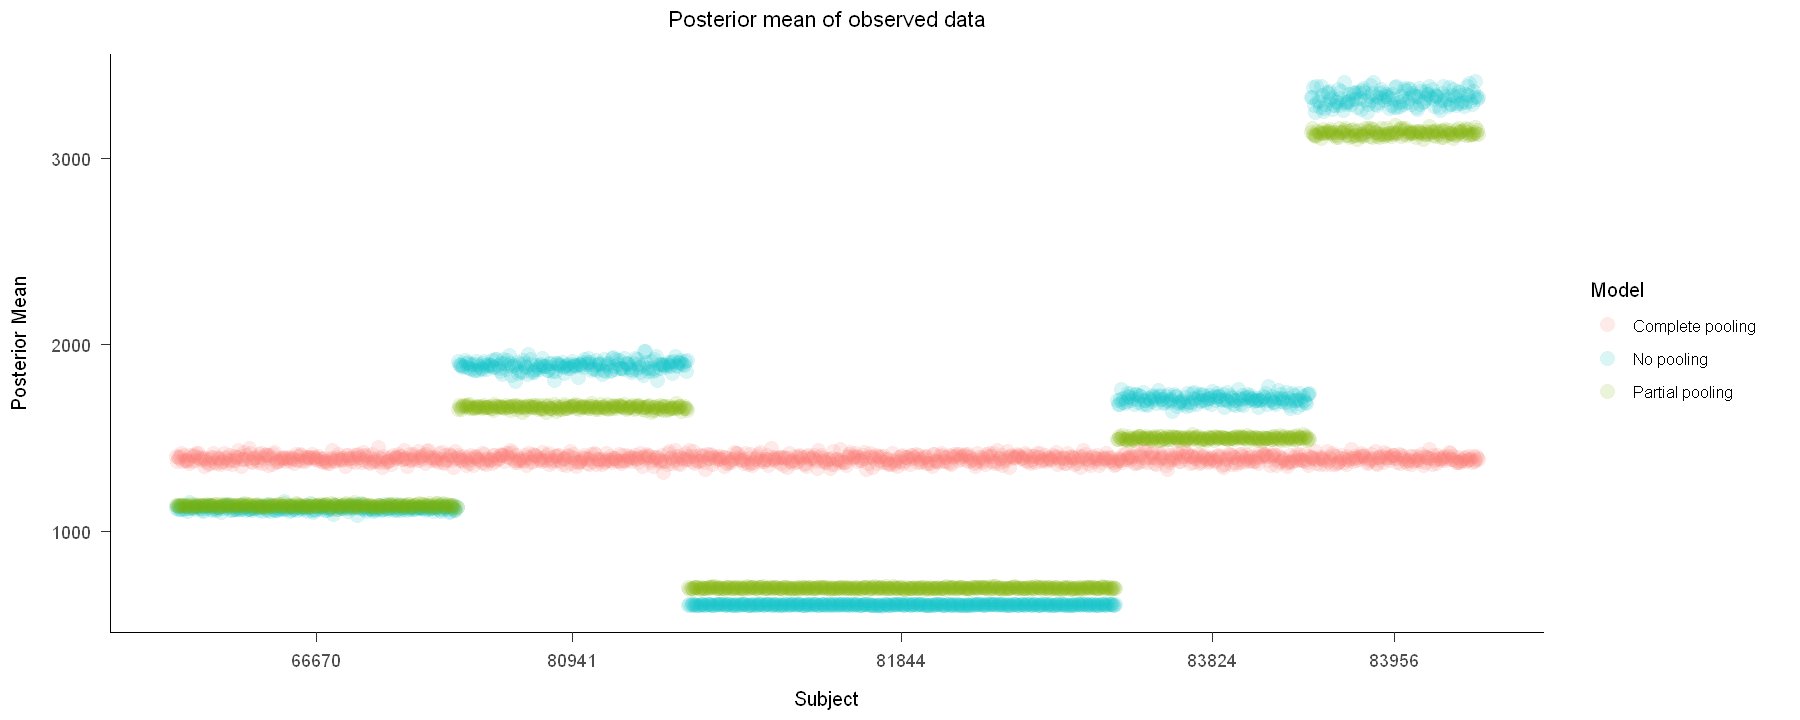

In [368]:
# 检查并转换subject列类型
complete_hdi_sum <- complete_hdi_sum %>%
  dplyr::mutate(subject = as.factor(subject))  # 转换为因子型

no_hdi_sum <- no_hdi_sum %>%
  dplyr::mutate(subject = as.factor(subject))

partial_hdi_sum <- partial_hdi_sum %>%
  dplyr::mutate(subject = as.factor(subject))

df_first5 <- df_first5 %>%
  dplyr::mutate(subject = as.factor(subject))

# 合并三个模型的后验预测数据
combined_data <- bind_rows(
  complete_hdi_sum %>% dplyr::mutate(model = "Complete pooling"),
  no_hdi_sum %>% dplyr::mutate(model = "No pooling"),
  partial_hdi_sum %>% dplyr::mutate(model = "Partial pooling")
)

# 计算每个被试的数据量和x轴刻度位置
count_per_subject <- df_first5 %>%
  dplyr::group_by(subject) %>%
  dplyr::summarise(count = n())

cumulative_count <- cumsum(count_per_subject$count)
xtick <- cumulative_count - count_per_subject$count / 2
subject_labels <- count_per_subject$subject

# 绘图
ggplot2::ggplot(combined_data, aes(x = obs_id, y = mean, color = model)) +
  ggplot2::geom_point(alpha = 0.15, size = 4, shape = 16) +
  ggplot2::scale_color_manual(values = c("Complete pooling" = "#F8766D",
                                "No pooling" = "#00BFC4",
                                "Partial pooling" = "#7CAE00")) +
  ggplot2::scale_x_continuous(
    breaks = xtick,
    labels = subject_labels
  ) +
  ggplot2::labs(
    title = "Posterior mean of observed data",
    x = "Subject",
    y = "Posterior Mean",
    color = "Model"
  ) +
  papaja::theme_apa()

收缩是指在分层模型中，特定群体的局部趋势(各被试的估计结果)被拉向或收缩向全局趋势(所有数据的整体趋势)的现象。  

$$  
\frac{\sigma^2_y}{\sigma^2_y + n_j \sigma^2_\mu} \overline{y}_{\text{global}} + \frac{n_j\sigma^2_\mu}{\sigma^2_y + n_j \sigma^2_\mu} \overline{y}_j  
$$  

* 收缩的大小 (即完全池化模型均值和非池化模型均值的权重)，取决于被试的数量 $n_j$ 以及 组内和组间变异性（$\sigma_y$和 $\sigma_μ$）的比。  
* 当被试的数量越少时，缩减率会增加。即我们越来越依赖全局趋势来了解一个组别很少 (可能意味着不可靠)的结果。  
* 当组别内的变异性$\sigma_y$与组别间的变异性 $\sigma_μ$ 相比较大时，缩减会增加。即当各被试之间的差异很小时，我们会更依赖于用全局趋势来理解其中一个被试的数据。  

层次模型在完全池化和无池化之间取得了平衡，优势在于：  

1. 将对不同群体(被试)的观察结果推广到更广泛的总体中  
2. 在了解任何单个群体时，借用所有其他群体的信息  

这也导致了它的缺点：  
* 如果被试数量少，并且组内变异大，那么我们对于总体和不同组别(被试)的估计都可能存在偏差

**bias-variance trade-off 偏差-方差权衡**  


|               | 完全池化                       | 非池化                                 | 部分池化               |  
| ------------- | ------------------------------ | -------------------------------------- | ---------------------- |  
| 特点          | 仅考虑总体的变异，模型过于简单 | 仅考虑各组别的差异，结果难以推广到总体 | 同时考虑组间和组内变异 |  
| 偏差-方差权衡 | 有较高的偏差和较低的方差       | 较低的偏差和较高的方差                 | 更为平衡               |  


## 模型评估

在第十一课中，通过示例介绍了 MAE的计算方法。本节课中也将通过MAE指标对三个不同的模型进行评估，以比较它们的表现。

In [364]:
calculate_mae <- function(hdi_sum, obs = "y", pred = "mean") {
  observed_data <- hdi_sum[[obs]]
  posterior_predictive <- hdi_sum[[pred]]
  mae <- stats::median(abs(observed_data - posterior_predictive))
  return(mae)
}

In [365]:
comolete_mae <- calculate_mae(complete_hdi_sum)
no_mae <- calculate_mae(no_hdi_sum)
partial_mae <- calculate_mae(partial_hdi_sum)

# 比较结果
mae_comparison <- data.frame(
  model = c("Complete Model", "No Model", "Partial Model"),
  mae = c(comolete_mae, no_mae, partial_mae)
)

print(mae_comparison)

           model      mae
1 Complete Model 772.7507
2       No Model 401.8186
3  Partial Model 381.4318


根据MAE值的结果可以看出，部分池化模型的MAE值约为 381.43 ，是三种模型中误差最小的。

这表明部分池化模型的表现优于其他两种模型。


## 预测新组的数据  

* 我们可以根据当前的层级模型对新组别的数据进行预测，如被试 31727。  

In [366]:
# 选择被试为"31727"且percentCoherence为5的数据
new_data <- df_raw %>%
  dplyr::filter(subject == 31727 & percentCoherence == 5)

# 建立索引 'subj_id' 和 'obs_id'
new_data <- new_data %>%
  dplyr::mutate(
    subj_id = subject,
    obs_id = dplyr::row_number()
  )

head(new_data)

,subject,blkNum,trlNum,coherentDots,numberofDots,percentCoherence,winningDirection,response,correct,eventCount,averageFrameRate,RT,subj_id,obs_id
,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>
1,31727,2,3,2,40,5,left,right,0,15,15.322,979,31727,1
2,31727,3,8,2,40,5,left,right,0,40,14.276,2802,31727,2
3,31727,3,10,2,40,5,right,right,1,24,14.303,1678,31727,3
4,31727,3,14,2,40,5,right,right,1,19,14.559,1305,31727,4
5,31727,3,16,2,40,5,right,left,0,25,14.451,1730,31727,5
6,31727,3,18,2,40,5,left,left,1,33,14.329,2303,31727,6


进行预测时，我们将使用新数据 new_data

In [370]:
# 拟合brms模型
partial_pooled_pred <- brms::brm(
  formula = log(RT) ~ 0 + (1 | subject),  # 1|subject表示随机截距，对应new_mu
  data = new_data,
  chains = 4,
  iter = 5000,
  warmup = 1000,
  seed = 84735,
)

# 进行后验预测（基于拟合的模型）
pred_trace <- brms::posterior_predict(
  partial_pooled_pred,
  newdata = new_data,
  seed = 84735
)

# 查看后验预测结果
# pred_trace是一个矩阵，行对应后验样本，列对应观测值
dim(pred_trace)  # 查看维度
head(pred_trace[, 1:5])  # 查看前5个观测值的前几个后验预测样本

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 7e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.7 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 5000 [  0%]  (Warmup)
Chain 1: Iteration:  500 / 5000 [ 10%]  (Warmup)
Chain 1: Iteration: 1000 / 5000 [ 20%]  (Warmup)
Chain 1: Iteration: 1001 / 5000 [ 20%]  (Sampling)
Chain 1: Iteration: 1500 / 5000 [ 30%]  (Sampling)
Chain 1: Iteration: 2000 / 5000 [ 40%]  (Sampling)
Chain 1: Iteration: 2500 / 5000 [ 50%]  (Sampling)
Chain 1: Iteration: 3000 / 5000 [ 60%]  (Sampling)
Chain 1: Iteration: 3500 / 5000 [ 70%]  (Sampling)
Chain 1: Iteration: 4000 / 5000 [ 80%]  (Sampling)
Chain 1: Iteration: 4500 / 5000 [ 90%]  (Sampling)
Chain 1: Iteration: 5000 / 5000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 4.808 seconds (Warm-up)
Chain 1:                20.92 seconds (Sampling)
Chain 1:                2

[1] 16000   277

7.312209,7.414551,7.283241,6.892375,7.428881
7.687599,6.412529,6.578555,6.555267,6.759829
7.151147,7.058188,7.383938,7.175348,7.227314
8.370541,6.656872,7.232969,7.379924,8.085909
7.193764,6.299640,6.634708,7.217637,7.255529
6.137239,6.213766,6.694256,7.086081,7.263197


对预测数据进行转换并进行可视化：

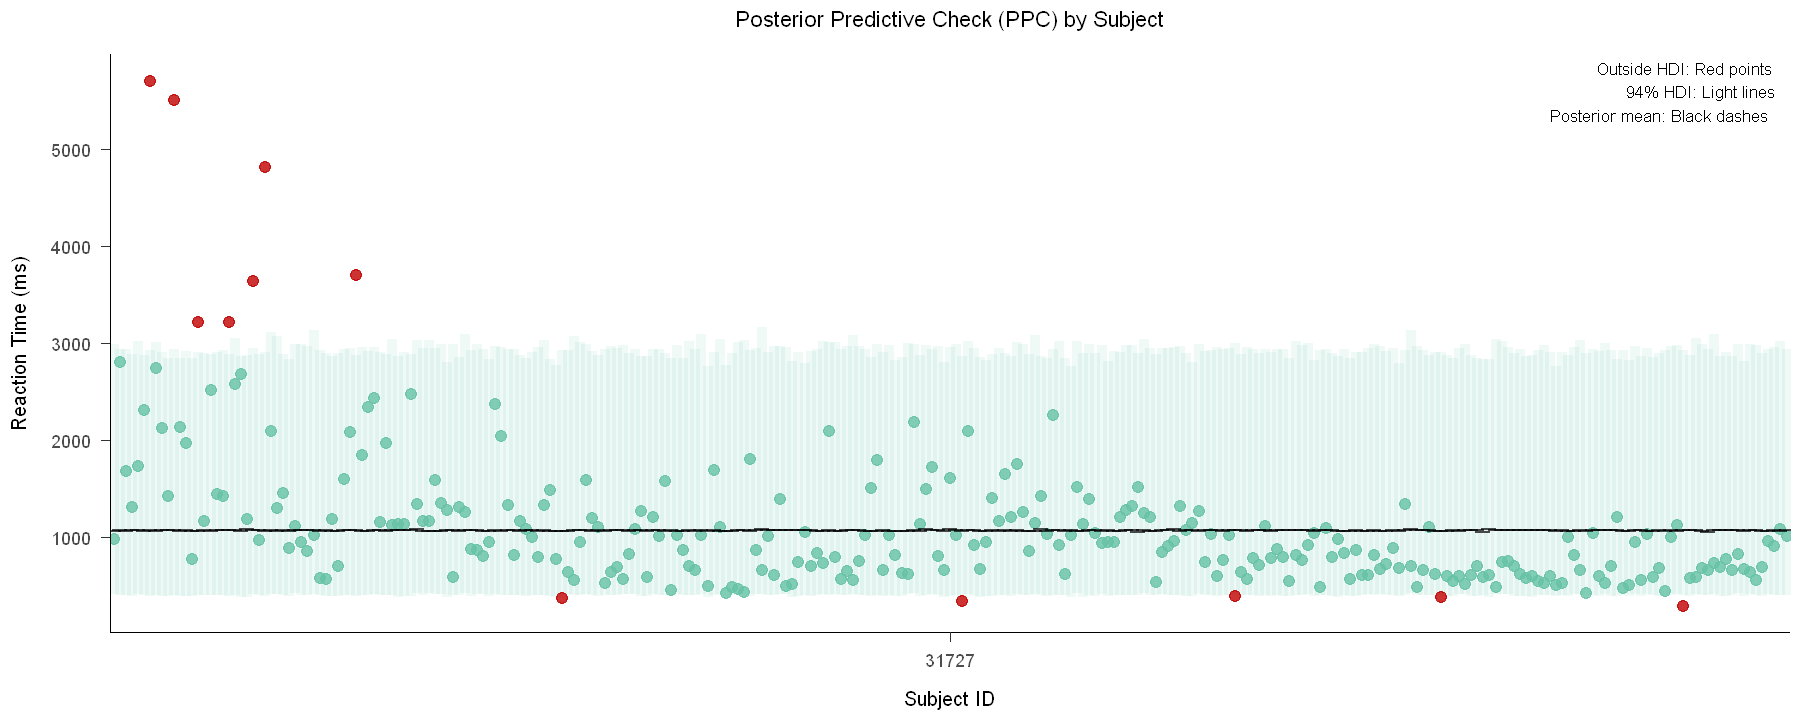

In [371]:
inv_log_hdi_sum <- function(hdi_sum) {
  # 对均值、HDI下限和上限进行逆对数转换
  df <- dplyr::mutate(
    hdi_sum,
    mean = inv_log(mean, sd),  # 转换均值
    Q2.5 = inv_log(Q2.5, sd),   # 转换2.5%分位数（HDI下限）
    Q97.5 = inv_log(Q97.5, sd)  # 转换97.5%分位数（HDI上限）
  )
  
  return(df)
}

ppc <- brms::posterior_predict(partial_pooled_pred)
pred_hdi_sum = ppc_sum(ppc,data=new_data,y = "RT")
pred_hdi_sum = inv_log_hdi_sum(pred_hdi_sum)
ppc_plot(pred_hdi_sum)

## 开放式练习  

在本次的练习中，层级数据表现为来自多个站点（Site）的自我控制分数，你可以选择完善完全池化、非池化、部分池化模型的练习代码，推荐选择使用brm构建分层模型，并思考分层模型带来的收缩效应 (shrinkake)。  

🔔 针对brm构建分层模型的提示：  
- 使用部分池化中的第一种公式构建分层模型时，提示：可使用`"scontrol ~ 0 + (1|Site)"`构建模型。  

> * 数据来源: Hu, C.-P. et al. (2018). Raw data from the Human Penguin Project. Open Science Framework. https://doi.org/10.17605/OSF.IO/H52D3   
> * 自我控制量表来源：Tangney, J. P., Baumeister, R. F. & Boone, A. L. High self-control predicts good adjustment, less pathology, better grades, and interpersonal success. J. Pers. 72, 271–324 (2004).

In [ ]:
# 安装和加载包
options(repos = c(CRAN = "https://mirrors.tuna.tsinghua.edu.cn/CRAN/"))
if (!requireNamespace('pacman', quietly = TRUE)) {
    install.packages('pacman')
}
pacman::p_load("tidyverse","ggplot2", "dplyr","gridExtra","patchwork","papaja", "bayesplot",
               "rstan","bridgesampling", 'logspline', "easystats", "brms", "RColorBrewer", "bayestestR") 
options(warn = -1)  # 抑制警告

In [372]:
# 导入数据
df_raw <- tryCatch({
  read.csv('/home/mw/input/bayes3797/Data_Sum_HPP_Multi_Site_Share.csv')
}, error = function(e) {
  read.csv('data/Data_Sum_HPP_Multi_Site_Share.csv')
})

df_raw[1:10, c("Site","scontrol")] # 显示前十行的数据

,Site,scontrol
,<chr>,<int>
1,Bamberg,41
2,Bamberg,36
3,Bamberg,31
4,Bamberg,40
5,Bamberg,43
6,Bamberg,42
7,Bamberg,44
8,Bamberg,45
9,Bamberg,39


### 数据可视化  

将所有站点的自我控制分数进行可视化，可以发现：  

* 有的组存在较多极端值  

* 组与组之间的均值不同

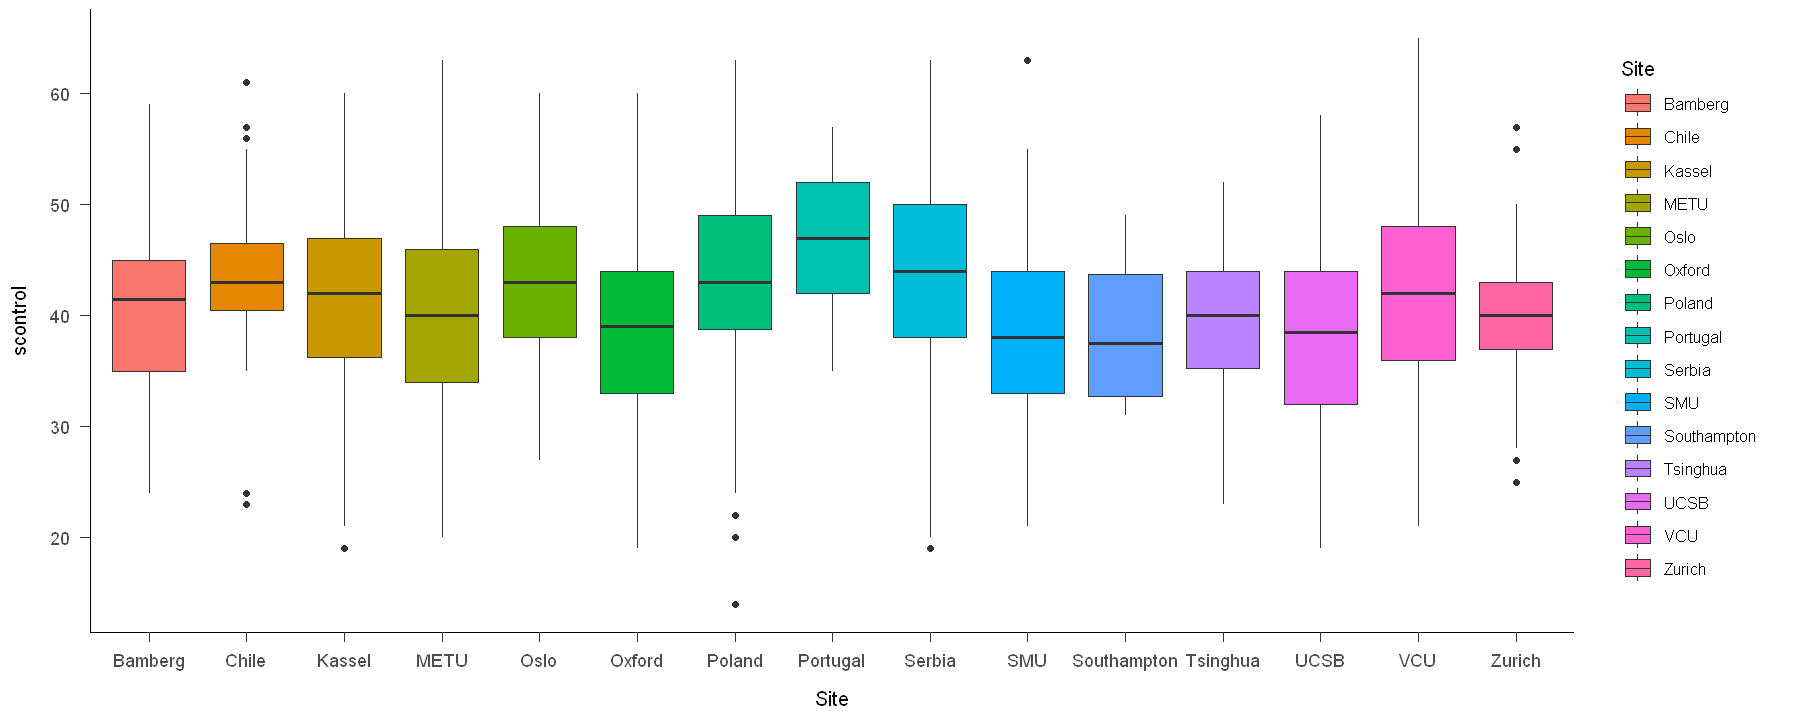

In [373]:
options(repr.plot.width = 15, repr.plot.height = 6)
plot <- ggplot2::ggplot(data = df_raw, aes(x = Site, y = scontrol, fill = Site)) +
  ggplot2::geom_boxplot() +
  ggplot2::theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +  # 旋转x轴标签
  papaja::theme_apa() 
# 显示图形
print(plot)

In [259]:
# 选取5个站点
first5_site <- c('Southampton', 'METU', 'Kassel', 'Tsinghua', 'Oslo')
df_first5 <- df_raw %>%
  dplyr::filter(Site %in% first5_site)

# 为site生成索引
df_first5 <- df_first5 %>%
  dplyr::mutate(
    site_idx = as.integer(factor(Site, levels = first5_site)) - 1,  # R因子从1开始，减1以匹配Python的0索引
    obs_id = dplyr::row_number() - 1  # R行号从1开始，减1以匹配Python的0索引
  )

# 设置索引，方便之后调用数据
df_first5 <- df_first5 %>%
  dplyr::mutate(
    Site = factor(Site, levels = first5_site)  # 确保Site按指定顺序排列
  ) %>%
  tibble::column_to_rownames(var = "obs_id")  # 将obs_id设为行名

# 查看前10行数据
head(df_first5, 10)

,age,anxiety,anxiety_r,artgluctot,attachhome,attachphone,AvgHumidity,avgtemp,avoidance,avoidance_r,⋯,scontrol,sex,Site,smoke,socialdiversity,socialembedded,socTherm,soliTherm,stress,site_idx
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<fct>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>
0,1955,3.500000,0.32378853,0,3.222222,3.666667,89,36.300,3.777778,1.0614738,⋯,47,1,Kassel,2,6,3,3.0,3.125,30,2
1,1959,1.500000,-1.38045564,0,4.444444,2.111111,NA,36.600,2.722222,-0.1248793,⋯,44,2,Kassel,2,7,4,2.4,3.125,30,2
2,1965,1.333333,-1.52247598,0,3.666667,2.000000,NA,35.450,2.611111,-0.2497585,⋯,47,1,Kassel,2,5,2,3.8,2.375,31,2
3,1966,3.222222,0.08708795,0,4.333333,1.000000,NA,36.630,3.166667,0.3746378,⋯,37,2,Kassel,2,9,2,3.6,2.875,47,2
4,1969,3.444444,0.27644841,0,3.555556,1.444444,69,36.465,3.222222,0.4370774,⋯,33,2,Kassel,2,11,3,2.2,2.750,50,2
5,1976,2.444444,-0.57567367,0,4.555556,1.444444,73,36.500,2.222222,-0.6868360,⋯,37,2,Kassel,2,12,3,3.2,2.625,42,2
6,1979,3.500000,0.32378853,0,4.111111,2.777778,68,35.300,3.555556,0.8117152,⋯,37,1,Kassel,2,7,2,2.8,4.125,37,2
7,1979,1.444444,-1.42779575,0,4.777778,3.000000,54,36.100,2.222222,-0.6868360,⋯,48,2,Kassel,2,8,2,3.4,2.750,33,2
8,1980,2.888889,-0.19695275,0,4.111111,2.333333,NA,36.400,3.388889,0.6243963,⋯,38,1,Kassel,1,9,4,2.8,3.750,42,2


## 完全池化模型  
### 模型定义及MCMC采样  

$$  
\begin{split}  
Y_{ij} | \mu, \sigma & \sim N(\mu, \sigma^2) \\  
\mu    & \sim N(0, 50^2) \\  
\sigma & \sim \text{Exp}(1) \\  
\end{split}  
$$  

根据公式使用 brm 定义模型：

In [ ]:
##--------------------------------------------------
#      提示：对...中的内容进行修改
#---------------------------------------------------

# 拟合完全池化模型，也可以尝试自定义先验~
complete_pooled_model <- brms::brm(
  formula = ...,  # 只包含截距项
  data = df_first5,
  family = gaussian(),
  # prior = ...,
  chains = 4,
  iter = 2000,
  warmup = 1000,
  seed = 84735,
  control = list(adapt_delta = 0.95)
)

In [ ]:
# 查看采样结果
summary(...) # 填入拟合的模型

In [ ]:
posterior_samples <- as.array(...) # 填入拟合的模型

bayesplot::mcmc_trace(
  posterior_samples,  # 后验样本数组
  pars = c("Intercept", "sigma"),  # 要绘制的参数
  facet_args = list(nrow = 2, ncol = 1)
) +
  ggplot2::labs(title = "Trace Plots") +
  papaja::theme_apa()

In [ ]:
# 进行后验预测
bayesplot::pp_check(...) + # 填入拟合的模型
papaja::theme_apa()

In [ ]:
##--------------------------------------------------
#      提示：直接运行即可
#---------------------------------------------------

# 定义函数，计算 95%hdi
ppc_sum <- function(ppc, data, y = "scontrol") {
  # 计算每个观测值的后验预测均值
  ppc_mean <- apply(ppc, 2, mean)
  
  # 计算每个观测值的后验预测标准差
  ppc_sd <- apply(ppc, 2, sd)
  
  # 计算每个观测值的95% HDI
  ppc_hdi <- t(apply(ppc, 2, function(x) {
    hdi_result <- bayestestR::hdi(x, ci = 0.95)
    # 直接提取 CI_low 和 CI_high 列
    return(c(hdi_result$CI_low, hdi_result$CI_high))
  }))
  
  # 设置HDI矩阵的列名
  colnames(ppc_hdi) <- c("Q2.5", "Q97.5")
  
  # 构建结果数据框
  hdi_sum <- base::data.frame(
    mean = ppc_mean,              # 后验预测均值
    sd = ppc_sd,                  # 后验预测标准差
    Q2.5 = ppc_hdi[, "Q2.5"],     # 95% HDI下限
    Q97.5 = ppc_hdi[, "Q97.5"],   # 95% HDI上限
    y = data[[y]],                # 原始观测值
    obs_id = 1:nrow(data),        # 观测ID
    Site = data[["Site"]]   # 站点ID
  )
  
  return(hdi_sum)
}

# 计算后验预测的 95%hdi
# 生成后验预测
ppc <- brms::posterior_predict(complete_pooled_model)

# 调用函数计算HDI
hdi_sum <- ppc_sum(ppc, data = df_first5, y = "scontrol")

# 查看结果
head(hdi_sum)

In [ ]:
##--------------------------------------------------
#      提示：直接运行即可
#---------------------------------------------------

# 定义PPC绘图函数
ppc_plot <- function(hdi_sum, show_plot = TRUE) {
  df <- hdi_sum
  
  # 重置索引，创建obs_id列
  df <- dplyr::mutate(df, obs_id = dplyr::row_number() - 1)
  
  # 选择Seaborn调色板
  n_site <- length(unique(df$Site))
  palette <- RColorBrewer::brewer.pal(n = min(8, n_site), name = "Set2")
  if (n_site > 8) {
    palette <- grDevices::colorRampPalette(palette)(n_site)
  }
  
  # 创建颜色映射向量（为每个site分配一个颜色）
  site_colors <- stats::setNames(palette, levels(df$Site))
  
  # 映射颜色到新列
  df <- dplyr::mutate(df,
    # 深色：用于散点
    color_dark = site_colors[as.character(Site)],
    # 浅色：用于HDI区间
    color_light = scales::alpha(site_colors[as.character(Site)], 0.3)
  )
  
  # 根据是否落在可信区间内分配颜色
  df <- dplyr::mutate(df,
    color_dark = ifelse(
      (y >= Q2.5) & (y <= Q97.5), 
      color_dark, "#C00000"  # 红色表示超出HDI
    )
  )
  
  # 计算每个被试的中心位置，用于x轴刻度
  subject_centers <- dplyr::group_by(df, Site) %>%
    dplyr::summarise(min_id = min(obs_id), max_id = max(obs_id), center = (min_id + max_id) / 2,
    .groups = "drop"
    )
  
  # 创建ggplot对象
  p <- ggplot2::ggplot(df, ggplot2::aes(x = obs_id)) +
    
    # 绘制94%可信区间
    ggplot2::geom_linerange(
      ggplot2::aes(ymin = Q2.5, ymax = Q97.5),
      color = df$color_light, alpha = 0.1, size = 3, show.legend = FALSE
    ) +
    
    # 各被试散点图数据
    ggplot2::geom_point(
      ggplot2::aes(y = y), color = df$color_dark, alpha = 0.8, size = 3
    ) +
    
    # 绘制后验预测均值（使用横线标记）
    ggplot2::geom_point(
      ggplot2::aes(y = mean), shape = "_", color = "black", alpha = 0.7,
      size = 5, show.legend = FALSE
    ) +
    
    # 设置x轴刻度（按站点分组）
    ggplot2::scale_x_continuous(
      breaks = subject_centers$center,
      labels = subject_centers$Site,
      expand = ggplot2::expansion(add = c(0.5, 0.5))
    ) +
    
    # 设置图形标题和标签
    ggplot2::labs(
      title = "Posterior Predictive Check (PPC) by Site",
      x = "Site",
      y = "Reaction Time (ms)"
    ) +
    papaja::theme_apa() +
    
    # 添加图例文本
    ggplot2::annotate(
      "text",
      x = Inf, y = Inf,
      label = "Outside HDI: Red points\n94% HDI: Light lines\nPosterior mean: Black dashes",
      hjust = 1.1, vjust = 1.1, size = 3.5
    )
  
  # 显示图形或返回ggplot对象
  if (show_plot) {
    print(p)
    return(invisible(p))
  } else {
    return(p)
  }
}

由于我们省略了分组信息，假测所有的观测值都来自同一正态分布，因此所有观测值的后验预测均值都是相似的  
* 纵坐标为自我控制分数的范围  
* 横坐标代表每个观测值的排序  
* 横线部分表示每个观测值的后验预测均值

In [ ]:
##--------------------------------------------------
#      提示：对...中的内容进行修改
#---------------------------------------------------

ppc_plot(hdi_sum=...)

## No pooling 非池化模型  

在complete pooled模型中，我们忽略了数据来自不同的站点这一事实  

现在我们考虑另外一种情况，我们**假设五个站点分别来自不同的分布，对五个站点进行不同的分析**  
* 注意：我们假定，各被试数据之间完全没有关联，不同站点之间彼此独立。  
* 从统计上讲，假定各站点之间的参数(例如均值$\mu$)没有关系，或者说是完全异质。  

### Group-specific parameters  

* 在完全池化模型中，我们使用了正态分布的参数来自总体层面；  

* 在非池化模型中，我们认为正态分布的参数在组与组之间是不同的(group-specific) ---- 可以认为么个站点的数据对应一个独立的正态分布模型  

![Image Name](https://cdn.kesci.com/upload/s5eh3sji4k.png?imageView2/0/w/960/h/960)  

1. 使用 $\mu_j$ 来表示每个站点的自我控制分数均值  

    * 不同站点的$\mu_j$不同  

    * 同一站点内的个体服从以 $\mu_j$ 为均值的正态分布模型  

3. 同样，使用 $\sigma_j$ 来表示每个站点内部自我控制分数的变异性  

    * 和 $\mu_j$ 类似，不同站点的 $\sigma_j$ 不同  
    * 同一站点内的个体服从以 $\sigma_j$ 为标准差的正态分布模型  


则对于站点 $j$ 内的个体来说，自我控制分数满足：  
$$  
Y_{ij} | \mu_j, \sigma \sim N(\mu_j, \sigma_j^2) \\  

\mu_j  \sim N(0, 50^2) \\  

\sigma_j \sim \text{Exp}(1) \\  
$$  

![Image Name](https://cdn.kesci.com/upload/s5eh3sji4k.png?imageView2/0/w/960/h/960)  

### 模型定义及MCMC采样  

根据公式定义模型：  

$$  
Y_{ij} | \mu_j, \sigma \sim N(\mu_j, \sigma_j^2) \\  

\mu_j  \sim N(0, 50^2) \\  

\sigma_j \sim \text{Exp}(1) \\  
$$  

- 考虑到数据有5个站点，即 j = 1,2,3,4,5。因此，$\mu_j$ 和 $\sigma_j$ 也有5个值。  

In [282]:
##--------------------------------------------------
#      提示：对...中的内容进行修改
#---------------------------------------------------

no_pooled_model <- brm(
  formula = ...,
  data = ...,
  family = gaussian(),
  # 为使模型收敛，此处j建议不自定义先验
  iter = 2000,
  warmup = 1000,
  chains = 4,
  cores = 4,
  seed = 84735,
  control = list(adapt_delta = 0.95)
)

Compiling Stan program...

Start sampling



### 查看后验参数估计  

- 可以发现，对于每个站点，均有不同的参数值 (包括 $\mu$ 和 $\sigma$)

In [ ]:
summary(no_pooled_model)

In [ ]:
##--------------------------------------------------
#      提示：对...中的内容进行修改
#---------------------------------------------------

options(repr.plot.width = 15, repr.plot.height = 20)

# 从 brms 模型中提取后验样本
posterior_samples <- as.array(...)

# 选择要绘制的参数（以其中三个站点为例）
target_pars <- c(
  "b_SiteSouthampton",
  "b_SiteMETU",
  "b_SiteKassel",
  "b_sigma_SiteSouthampton",
  "b_sigma_SiteMETU",
  "b_sigma_SiteKassel")

# 绘制迹图（trace plot）
bayesplot::mcmc_trace(
  posterior_samples,  # 后验样本数组
  pars = target_pars,  # 要绘制的参数
  facet_args = list(nrow = 6, ncol = 1)
) +
  ggplot2::labs(title = "Trace Plots") +
  papaja::theme_apa()

### 后验预测分布

In [ ]:
##--------------------------------------------------
#      提示：对...中的内容进行修改
#---------------------------------------------------

options(repr.plot.width = 15, repr.plot.height = 8)

bayesplot::pp_check(no_pooled_model) +
papaja::theme_apa()

In [ ]:
# 生成后验预测
ppc <- brms::posterior_predict(...)

# 调用函数计算HDI
no_hdi_sum <- ppc_sum(ppc, data = df_first5)

# 查看结果
head(no_hdi_sum)

In [ ]:
##--------------------------------------------------
#      提示：对...中的内容进行修改
#---------------------------------------------------

ppc_plot(hdi_sum=...)

## 部分池化模型  

层级模型的数学形式：  

$$  
\begin{array}{lrl}  
\text{Layer 1:} \hspace{0.5in} Y_{ij} | \mu_j, \sigma_y \sim N(\mu_j, \sigma_y^2) \hspace{0.05in} \text{根据站点均值生成个体数据}\\  

\text{Layer 2:} \hspace{0.5in} \mu_j | \mu, \sigma_\mu \stackrel{ind}{\sim} N(\mu, \sigma_\mu^2) \hspace{0.13in} \text{生成不同站点的均值}\\  

\text{Layer 3:}  \hspace{0.5in}\mu,\sigma_y,\sigma_\mu \hspace{0.85in}{超参数}\\  
\hspace{1in}\mu \sim N(40, 20^2) \\  
\hspace{1in}\sigma_y \sim \text{Exp}(1) \text{自我控制分数在组内的变异性} \\  
\hspace{1in} \sigma_\mu \sim \text{Exp}(1) \text{均值在组间的变异性} \\  
\end{array}  
$$  


1. 在最上层：  
    * 使用$\mu$来表示总体的$Y$(global average)，即总体而言，自我控制分数的均值  
    * 使用$\sigma_\mu$来表示组与组之间在$Y$均值上的变异性  
    * 使用$\sigma_y$来表示每个组内部$Y$的变异性(这里我们假设每个组内部的变异性相同)  
2. 在第二层：  
    * 使用$\mu_j$来表示每个组$Y$的均值，而$\mu_j$服从$N(\mu, \sigma_\mu^2)$，这两个参数是从上一层得到的  
3. 在第三层：  
    * 使用$Y_{ij}$来表示组内每个个体的$Y$，而$Y_{ij}$服从$N(\mu_j, \sigma_y^2)$，这两个参数是从上一层得到的  

![Image Name](https://cdn.kesci.com/upload/s5enwlkkz8.png?imageView2/0/w/500/h/500)  


### 模型定义及MCMC采样  

根据公式定义模型：  

$$  
\begin{array}{lrl}  
\text{Layer 1:} \hspace{0.5in} Y_{ij} | \mu_j, \sigma_y \sim N(\mu_j, \sigma_y^2) \hspace{0.05in} \text{根据站点均值生成个体数据}\\  

\text{Layer 2:} \hspace{0.5in} \mu_j | \mu, \sigma_\mu \stackrel{ind}{\sim} N(\mu, \sigma_\mu^2) \hspace{0.13in} \text{生成不同站点的均值}\\  

\text{Layer 3:}  \hspace{0.5in}\mu,\sigma_y,\sigma_\mu \hspace{0.85in}{超参数}\\  
\hspace{1in}\mu \sim N(40, 20^2) \\  
\hspace{1in}\sigma_y \sim \text{Exp}(1) \text{自我控制分数在组内的变异性} \\  
\hspace{1in} \sigma_\mu \sim \text{Exp}(1) \text{均值在组间的变异性} \\  
\end{array}  
$$  

- 相对于非池化模型。部分池化模型的关键在于定义，站点参数在总体上的变异
- 其次，是相似于非池化模型，个体数据在不同站点分布上的变异



In [290]:
#--------------------------------------------------
#      提示：对...中的内容进行修改
#---------------------------------------------------

# 定义部分池化模型
partial_pooled_model <- brms::brm(
  formula = ...,
  data = ...,
  family = gaussian(),
  iter = 5000,
  warmup = 1000,
  chains = 4,
  cores = 4,
  seed = 84735,
  control = list(adapt_delta = 0.95)
)

Compiling Stan program...

Start sampling



### 查看后验参数估计  

In [ ]:
##--------------------------------------------------
#      提示：对...中的内容进行修改
#---------------------------------------------------
summary(partial_pooled_model)

In [293]:
post_samples <- brms::posterior_samples(partial_pooled_model)
# # 查看完整参数名
print(colnames(post_samples))

[1] "sd_Site__Intercept"            "sigma"                        
[3] "r_Site[Southampton,Intercept]" "r_Site[METU,Intercept]"       
[5] "r_Site[Kassel,Intercept]"      "r_Site[Tsinghua,Intercept]"   
[7] "r_Site[Oslo,Intercept]"        "lprior"                       
[9] "lp__"                         


In [ ]:
##--------------------------------------------------
#      提示：对...中的内容进行修改
#---------------------------------------------------

options(repr.plot.width = 15, repr.plot.height = 18)

# 从 brms 模型中提取后验样本
posterior_samples <- as.array(...)

target_pars <- c(
  # 每个被试的均值（随机截距）
  "r_Site[Southampton,Intercept]",
  "r_Site[METU,Intercept]",
  "r_Site[Kassel,Intercept]",
  "r_Site[Tsinghua,Intercept]",
  "r_Site[Oslo,Intercept]",
  "sd_Site__Intercept"
)

# 绘制迹图（调整nrow为参数数量）
bayesplot::mcmc_trace(
  posterior_samples,
  pars = target_pars,
  facet_args = list(nrow = 6, ncol = 1)
) +
  papaja::theme_apa()

### 后验预测分布  

* 可以看到相比于非池化模型，在层级模型中不同组的后验预测可信区间的长度、后验预测均值都更为接近

In [ ]:
##--------------------------------------------------
#      提示：对...中的内容进行修改
#---------------------------------------------------

options(repr.plot.width = 15, repr.plot.height = 6)
bayesplot::pp_check(...) 

In [ ]:
##--------------------------------------------------
#      提示：对...中的内容进行修改
#---------------------------------------------------

ppc <- brms::posterior_predict(...)
partial_hdi_sum <- ppc_sum(ppc, data = df_first5, y = "scontrol")
ppc_plot(hdi_sum=partial_hdi_sum)